In [43]:
import numpy as np
import matplotlib.pyplot as plt
import struct
from matplotlib.patches import Rectangle, ConnectionPatch

FIGURE_WIDTH = 8
FIGURE_HEIGHT = 4
LEGEND_FONT_SIZE = 12
LABELS_FONT_SIZE = 18
TICK_FONT_SIZE = 14
TITLE_FONT_SIZE = 18
FONT_WINDOWS = "Times New Roman"
FONT_LINUX = "Nimbus Roman"
FIGURES_PATH = "../paper_figures/OJCAS"

## Funções reais

In [44]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def relu(x):
    return np.maximum(0.0, x)

def wsilu(x, alpha=4.0):
    return x * sigmoid(alpha * x)

def wsilu_real(x, w=4.0):
    return np.float16(x / (1.0 + np.exp(-4 * x)))

## Aproximações 

### LUT 512

In [45]:
def wsilu_lut_512(x):
  lut_hex = [
0x3800, 0x3804, 0x3808, 0x380c, 0x3810, 0x3814, 0x3818, 0x381c, 0x3820, 0x3824, 0x3828, 0x382c, 0x3830, 0x3834, 0x3838, 0x383c, 0x3840, 0x3844, 0x3848, 0x384c, 0x3850, 0x3854, 0x3858, 0x385c, 0x3860, 0x3864, 0x3868, 0x386b, 0x386f, 0x3874, 0x3877, 0x387b, 0x387f, 0x3883, 0x3887, 0x388b, 0x388f, 0x3893, 0x3897, 0x389b, 0x389f, 0x38a2, 0x38a6, 0x38aa, 0x38ae, 0x38b2, 0x38b6, 0x38b9, 0x38be, 0x38c2, 0x38c5, 0x38c9, 0x38cd, 0x38d1, 0x38d5, 0x38d9, 0x38dd, 0x38e0, 0x38e4, 0x38e8, 0x38ec, 0x38ef, 0x38f3, 0x38f7, 0x38fb, 0x38ff, 0x3902, 0x3907, 0x390a, 0x390d, 0x3912, 0x3915, 0x3918, 0x391c, 0x3920, 0x3924, 0x3927, 0x392b, 0x392f, 0x3933, 0x3936, 0x3939, 0x393d, 0x3940, 0x3945, 0x3948, 0x394c, 0x394f, 0x3953, 0x3956, 0x395a, 0x395d, 0x3961, 0x3965, 0x3968, 0x396b, 0x396f, 0x3972, 0x3976, 0x397a, 0x397d, 0x3980, 0x3983, 0x3987, 0x398b, 0x398e, 0x3992, 0x3995, 0x3998, 0x399b, 0x399e, 0x39a2, 0x39a5, 0x39a8, 0x39ac, 0x39af, 0x39b2, 0x39b6, 0x39ba, 0x39bd, 0x39c0, 0x39c3, 0x39c6, 0x39c9, 0x39cc, 0x39cf, 0x39d3, 0x39d6, 0x39d9, 0x39dc, 0x39df, 0x39e3, 0x39e6, 0x39e9, 0x39eb, 0x39ef, 0x39f2, 0x39f5, 0x39f9, 0x39fb, 0x39fe, 0x3a02, 0x3a04, 0x3a07, 0x3a0b, 0x3a0d, 0x3a10, 0x3a13, 0x3a16, 0x3a18, 0x3a1c, 0x3a1e, 0x3a22, 0x3a24, 0x3a26, 0x3a2a, 0x3a2c, 0x3a30, 0x3a32, 0x3a35, 0x3a37, 0x3a3b, 0x3a3d, 0x3a41, 0x3a43, 0x3a46, 0x3a48, 0x3a4b, 0x3a4d, 0x3a50, 0x3a53, 0x3a56, 0x3a58, 0x3a5b, 0x3a5d, 0x3a60, 0x3a63, 0x3a65, 0x3a68, 0x3a6a, 0x3a6d, 0x3a6f, 0x3a72, 0x3a75, 0x3a77, 0x3a7a, 0x3a7b, 0x3a7e, 0x3a80, 0x3a83, 0x3a86, 0x3a88, 0x3a8b, 0x3a8c, 0x3a8f, 0x3a92, 0x3a93, 0x3a96, 0x3a99, 0x3a9b, 0x3a9d, 0x3a9f, 0x3aa2, 0x3aa3, 0x3aa6, 0x3aa9, 0x3aaa, 0x3aad, 0x3aaf, 0x3ab1, 0x3ab4, 0x3ab6, 0x3ab8, 0x3aba, 0x3abd, 0x3abe, 0x3ac1, 0x3ac2, 0x3ac5, 0x3ac7, 0x3ac8, 0x3acb, 0x3acc, 0x3acf, 0x3ad1, 0x3ad4, 0x3ad5, 0x3ad7, 0x3ad9, 0x3adb, 0x3adc, 0x3adf, 0x3ae1, 0x3ae2, 0x3ae4, 0x3ae7, 0x3ae8, 0x3aea, 0x3aeb, 0x3aee, 0x3af0, 0x3af1, 0x3af3, 0x3af6, 0x3af7, 0x3af9, 0x3afa, 0x3afc, 0x3afd, 0x3b00, 0x3b02, 0x3b04, 0x3b05, 0x3b07, 0x3b08, 0x3b0a, 0x3b0b, 0x3b10, 0x3b13, 0x3b16, 0x3b19, 0x3b1c, 0x3b20, 0x3b23, 0x3b26, 0x3b29, 0x3b2b, 0x3b2e, 0x3b31, 0x3b34, 0x3b38, 0x3b39, 0x3b3d, 0x3b40, 0x3b42, 0x3b45, 0x3b48, 0x3b4a, 0x3b4d, 0x3b4f, 0x3b52, 0x3b54, 0x3b57, 0x3b59, 0x3b5b, 0x3b5e, 0x3b60, 0x3b63, 0x3b65, 0x3b66, 0x3b68, 0x3b6c, 0x3b6d, 0x3b6f, 0x3b71, 0x3b74, 0x3b76, 0x3b78, 0x3b79, 0x3b7b, 0x3b7d, 0x3b7f, 0x3b80, 0x3b84, 0x3b86, 0x3b88, 0x3b89, 0x3b8b, 0x3b8b, 0x3b8d, 0x3b8f, 0x3b90, 0x3b92, 0x3b94, 0x3b96, 0x3b98, 0x3b99, 0x3b9b, 0x3b9b, 0x3b9d, 0x3b9f, 0x3ba1, 0x3ba2, 0x3ba2, 0x3ba4, 0x3ba6, 0x3ba8, 0x3ba8, 0x3baa, 0x3bac, 0x3bac, 0x3bad, 0x3baf, 0x3baf, 0x3bb1, 0x3bb3, 0x3bb3, 0x3bb5, 0x3bb7, 0x3bb7, 0x3bb9, 0x3bb9, 0x3bba, 0x3bba, 0x3bbc, 0x3bbe, 0x3bbe, 0x3bc0, 0x3bc0, 0x3bc2, 0x3bc2, 0x3bc4, 0x3bc4, 0x3bc6, 0x3bc6, 0x3bc6, 0x3bc8, 0x3bc8, 0x3bc9, 0x3bc9, 0x3bcb, 0x3bcb, 0x3bcd, 0x3bcd, 0x3bcd, 0x3bcf, 0x3bcf, 0x3bd1, 0x3bd1, 0x3bd1, 0x3bd3, 0x3bd3, 0x3bd3, 0x3bd5, 0x3bd5, 0x3bd5, 0x3bd7, 0x3bd7, 0x3bd7, 0x3bd9, 0x3bd9, 0x3bd9, 0x3bdb, 0x3bdb, 0x3bdb, 0x3bdd, 0x3bdd, 0x3bdf, 0x3bdf, 0x3be0, 0x3be0, 0x3be2, 0x3be2, 0x3be4, 0x3be4, 0x3be6, 0x3be6, 0x3be8, 0x3be8, 0x3be8, 0x3bea, 0x3bea, 0x3bea, 0x3bec, 0x3bec, 0x3bec, 0x3bee, 0x3bee, 0x3bee, 0x3bee, 0x3bf0, 0x3bf0, 0x3bf0, 0x3bf0, 0x3bf2, 0x3bf2, 0x3bf2, 0x3bf2, 0x3bf4, 0x3bf4, 0x3bf4, 0x3bf4, 0x3bf4, 0x3bf4, 0x3bf6, 0x3bf6, 0x3bf6, 0x3bf6, 0x3bf6, 0x3bf6, 0x3bf8, 0x3bf8, 0x3bf8, 0x3bf8, 0x3bf8, 0x3bf8, 0x3bf8, 0x3bf8, 0x3bfa, 0x3bfa, 0x3bfa, 0x3bfa, 0x3bfa, 0x3bfa, 0x3bfa, 0x3bfa, 0x3bfa, 0x3bfa, 0x3bfa, 0x3bfc, 0x3bfc, 0x3bfc, 0x3bfc, 0x3bfc, 0x3bfc, 0x3bfc, 0x3bfc, 0x3bfc, 0x3bfc, 0x3bfc, 0x3bfc, 0x3bfc, 0x3bfc, 0x3bfc, 0x3bfc, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3c00, 0x3c00, 0x3c00, 0x3c00, 0x3c00, 0x3c00, 0x3c00, 0x3c00, 0x3c00, 0x3c00, 0x3c00, 0x3c00]
  lut_float16 = np.array([struct.unpack('>e', struct.pack('>H', v))[0] for v in lut_hex], dtype=np.float16)

  # --- Constantes do VHDL ---
  LIMIT_1= np.float16(0.5)
  LIMIT_2= np.float16(1.0)
  LIMIT_3= np.float16(1.5)
  LIMIT_4= np.float16(2.0)
  N_1 = 128 *2
  N_2= 64*2
  N_3= 32*2
  N_4= 32*2
  LUT_SIZE = len(lut_float16)

  x_q = np.float16(x)
  abs_x = np.abs(x_q)
  if(x < np.float16(-2.0)):
    y_sigmoid = np.float16(0)
  else:

    if abs_x <= LIMIT_1:
        scaled = int((abs_x / LIMIT_1) * N_1)
    elif abs_x <= LIMIT_2:
        scaled = N_1 + int(((abs_x - LIMIT_1) / (LIMIT_2 - LIMIT_1)) * N_2)
    elif abs_x <= LIMIT_3:
        scaled = N_1 + N_2 + int(((abs_x - LIMIT_2) / (LIMIT_3 - LIMIT_2)) * N_3)
    elif abs_x <= LIMIT_4:
        scaled = N_1 + N_2 + N_3 + int(((abs_x - LIMIT_3) / (LIMIT_4 - LIMIT_3)) * N_4)
    else:
        scaled = LUT_SIZE - 1

    idx = max(0, min(LUT_SIZE - 1, scaled))
    sigmoid_val = lut_float16[idx]

      # Aplica a simetria para valores negativos de x
    if x_q < 0:
        y_sigmoid = np.float16(1.0) - sigmoid_val
    else:
        y_sigmoid = sigmoid_val

  return x_q * y_sigmoid


### LUT 256

In [46]:
def wsilu_lut_256(x):
  lut_hex = [
0x3800, 0x3808, 0x3810, 0x3818, 0x3820, 0x3828, 0x3830, 0x3838, 0x3840, 0x3848, 0x3850, 0x3858, 0x3860, 0x3868, 0x386f, 0x3877, 0x387f, 0x3887, 0x388f, 0x3897, 0x389f, 0x38a6, 0x38ae, 0x38b6, 0x38be, 0x38c5, 0x38cd, 0x38d5, 0x38dd, 0x38e4, 0x38ec, 0x38f3, 0x38fb, 0x3902, 0x390a, 0x3912, 0x3918, 0x3920, 0x3927, 0x392f, 0x3936, 0x393d, 0x3945, 0x394c, 0x3953, 0x395a, 0x3961, 0x3968, 0x396f, 0x3976, 0x397d, 0x3983, 0x398b, 0x3992, 0x3998, 0x399e, 0x39a5, 0x39ac, 0x39b2, 0x39ba, 0x39c0, 0x39c6, 0x39cc, 0x39d3, 0x39d9, 0x39df, 0x39e6, 0x39eb, 0x39f2, 0x39f9, 0x39fe, 0x3a04, 0x3a0b, 0x3a10, 0x3a16, 0x3a1c, 0x3a22, 0x3a26, 0x3a2c, 0x3a32, 0x3a37, 0x3a3d, 0x3a43, 0x3a48, 0x3a4d, 0x3a53, 0x3a58, 0x3a5d, 0x3a63, 0x3a68, 0x3a6d, 0x3a72, 0x3a77, 0x3a7b, 0x3a80, 0x3a86, 0x3a8b, 0x3a8f, 0x3a93, 0x3a99, 0x3a9d, 0x3aa2, 0x3aa6, 0x3aaa, 0x3aaf, 0x3ab4, 0x3ab8, 0x3abd, 0x3ac1, 0x3ac5, 0x3ac8, 0x3acc, 0x3ad1, 0x3ad5, 0x3ad9, 0x3adc, 0x3ae1, 0x3ae4, 0x3ae8, 0x3aeb, 0x3af0, 0x3af3, 0x3af7, 0x3afa, 0x3afd, 0x3b02, 0x3b05, 0x3b08, 0x3b0b, 0x3b13, 0x3b19, 0x3b20, 0x3b26, 0x3b2b, 0x3b31, 0x3b38, 0x3b3d, 0x3b42, 0x3b48, 0x3b4d, 0x3b52, 0x3b57, 0x3b5b, 0x3b60, 0x3b65, 0x3b68, 0x3b6d, 0x3b71, 0x3b76, 0x3b79, 0x3b7d, 0x3b80, 0x3b86, 0x3b89, 0x3b8b, 0x3b8f, 0x3b92, 0x3b96, 0x3b99, 0x3b9b, 0x3b9f, 0x3ba2, 0x3ba4, 0x3ba8, 0x3baa, 0x3bac, 0x3baf, 0x3bb1, 0x3bb3, 0x3bb7, 0x3bb9, 0x3bba, 0x3bbc, 0x3bbe, 0x3bc0, 0x3bc2, 0x3bc4, 0x3bc6, 0x3bc8, 0x3bc9, 0x3bcb, 0x3bcd, 0x3bcd, 0x3bcf, 0x3bd1, 0x3bd3, 0x3bd3, 0x3bd5, 0x3bd7, 0x3bd7, 0x3bd9, 0x3bdb, 0x3bdb, 0x3bdd, 0x3bdf, 0x3be0, 0x3be2, 0x3be4, 0x3be6, 0x3be8, 0x3bea, 0x3bea, 0x3bec, 0x3bee, 0x3bee, 0x3bf0, 0x3bf0, 0x3bf2, 0x3bf2, 0x3bf4, 0x3bf4, 0x3bf4, 0x3bf6, 0x3bf6, 0x3bf6, 0x3bf8, 0x3bf8, 0x3bf8, 0x3bf8, 0x3bfa, 0x3bfa, 0x3bfa, 0x3bfa, 0x3bfa, 0x3bfa, 0x3bfc, 0x3bfc, 0x3bfc, 0x3bfc, 0x3bfc, 0x3bfc, 0x3bfc, 0x3bfc, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3c00, 0x3c00, 0x3c00, 0x3c00, 0x3c00, 0x3c00]
  lut_float16 = np.array([struct.unpack('>e', struct.pack('>H', v))[0] for v in lut_hex], dtype=np.float16)

  # --- Constantes do VHDL ---
  LIMIT_1= np.float16(0.5)
  LIMIT_2= np.float16(1.0)
  LIMIT_3= np.float16(1.5)
  LIMIT_4= np.float16(2.0)
  N_1 = 128
  N_2= 64
  N_3= 32
  N_4= 32
  LUT_SIZE = len(lut_float16)

  x_q = np.float16(x)
  abs_x = np.abs(x_q)
  if(x < np.float16(-2.0)):
    y_sigmoid = np.float16(0)
  else:

    if abs_x <= LIMIT_1:
        scaled = int((abs_x / LIMIT_1) * N_1)
    elif abs_x <= LIMIT_2:
        scaled = N_1 + int(((abs_x - LIMIT_1) / (LIMIT_2 - LIMIT_1)) * N_2)
    elif abs_x <= LIMIT_3:
        scaled = N_1 + N_2 + int(((abs_x - LIMIT_2) / (LIMIT_3 - LIMIT_2)) * N_3)
    elif abs_x <= LIMIT_4:
        scaled = N_1 + N_2 + N_3 + int(((abs_x - LIMIT_3) / (LIMIT_4 - LIMIT_3)) * N_4)
    else:
        scaled = LUT_SIZE - 1

    idx = max(0, min(LUT_SIZE - 1, scaled))
    sigmoid_val = lut_float16[idx]

      # Aplica a simetria para valores negativos de x
    if x_q < 0:
        y_sigmoid = np.float16(1.0) - sigmoid_val
    else:
        y_sigmoid = sigmoid_val

  return x_q * y_sigmoid

  

### LUT 128

In [47]:
def wsilu_lut_128(x):
  lut_hex = [
            0x3800, 0x3810, 0x3820, 0x3830, 0x3840, 0x3850, 0x3860, 0x386f,
            0x387f, 0x388f, 0x389f, 0x38ae, 0x38be, 0x38cd, 0x38dd, 0x38ec,
            0x38fb, 0x390a, 0x3918, 0x3927, 0x3936, 0x3945, 0x3953, 0x3961,
            0x396f, 0x397d, 0x398b, 0x3998, 0x39a5, 0x39b2, 0x39c0, 0x39cc,
            0x39d9, 0x39e6, 0x39f2, 0x39fe, 0x3a0b, 0x3a16, 0x3a22, 0x3a2c,
            0x3a37, 0x3a43, 0x3a4d, 0x3a58, 0x3a63, 0x3a6d, 0x3a77, 0x3a80,
            0x3a8b, 0x3a93, 0x3a9d, 0x3aa6, 0x3aaf, 0x3ab8, 0x3ac1, 0x3ac8,
            0x3ad1, 0x3ad9, 0x3ae1, 0x3ae8, 0x3af0, 0x3af7, 0x3afd, 0x3b05,
            0x3b0b, 0x3b19, 0x3b26, 0x3b31, 0x3b3d, 0x3b48, 0x3b52, 0x3b5b,
            0x3b65, 0x3b6d, 0x3b76, 0x3b7d, 0x3b86, 0x3b8b, 0x3b92, 0x3b99,
            0x3b9f, 0x3ba4, 0x3baa, 0x3baf, 0x3bb3, 0x3bb9, 0x3bbc, 0x3bc0,
            0x3bc4, 0x3bc8, 0x3bcb, 0x3bcd, 0x3bd1, 0x3bd3, 0x3bd7, 0x3bd9,
            0x3bdb, 0x3bdf, 0x3be2, 0x3be6, 0x3bea, 0x3bec, 0x3bee, 0x3bf0,
            0x3bf2, 0x3bf4, 0x3bf6, 0x3bf6, 0x3bf8, 0x3bf8, 0x3bfa, 0x3bfa,
            0x3bfa, 0x3bfc, 0x3bfc, 0x3bfc, 0x3bfc, 0x3bfe, 0x3bfe, 0x3bfe,
            0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3c00, 0x3c00, 0x3c00]
  lut_float16 = np.array([struct.unpack('>e', struct.pack('>H', v))[0] for v in lut_hex], dtype=np.float16)

  # --- Constantes do VHDL ---
  LIMIT_1= np.float16(0.5)
  LIMIT_2= np.float16(1.0)
  LIMIT_3= np.float16(1.5)
  LIMIT_4= np.float16(2.0)
  N_1 = 64
  N_2= 32
  N_3= 16
  N_4= 16
  LUT_SIZE = len(lut_float16)

  x_q = np.float16(x)
  abs_x = np.abs(x_q)
  if(x < np.float16(-2.0)):
    y_sigmoid = np.float16(0)
  else:

    if abs_x <= LIMIT_1:
        scaled = int((abs_x / LIMIT_1) * N_1)
    elif abs_x <= LIMIT_2:
        scaled = N_1 + int(((abs_x - LIMIT_1) / (LIMIT_2 - LIMIT_1)) * N_2)
    elif abs_x <= LIMIT_3:
        scaled = N_1 + N_2 + int(((abs_x - LIMIT_2) / (LIMIT_3 - LIMIT_2)) * N_3)
    elif abs_x <= LIMIT_4:
        scaled = N_1 + N_2 + N_3 + int(((abs_x - LIMIT_3) / (LIMIT_4 - LIMIT_3)) * N_4)
    else:
        scaled = LUT_SIZE - 1

    idx = max(0, min(LUT_SIZE - 1, scaled))
    sigmoid_val = lut_float16[idx]

      # Aplica a simetria para valores negativos de x
    if x_q < 0:
        y_sigmoid = np.float16(1.0) - sigmoid_val
    else:
        y_sigmoid = sigmoid_val

  return x_q * y_sigmoid

  

### LUT 64

In [48]:
def wsilu_lut_64(x):
  lut_hex = [
0x3800, 0x3820, 0x3840, 0x3860, 0x387f, 0x389f, 0x38be, 0x38dd,
            0x38fb, 0x3918, 0x3936, 0x3953, 0x396f, 0x398b, 0x39a5, 0x39c0,
            0x39d9, 0x39f2, 0x3a0b, 0x3a22, 0x3a37, 0x3a4d, 0x3a63, 0x3a77,
            0x3a8b, 0x3a9d, 0x3aaf, 0x3ac1, 0x3ad1, 0x3ae1, 0x3af0, 0x3afd,
            0x3b0b, 0x3b26, 0x3b3d, 0x3b52, 0x3b65, 0x3b76, 0x3b86, 0x3b92,
            0x3b9f, 0x3baa, 0x3bb3, 0x3bbc, 0x3bc4, 0x3bcb, 0x3bd1, 0x3bd7,
            0x3bdb, 0x3be2, 0x3bea, 0x3bee, 0x3bf2, 0x3bf6, 0x3bf8, 0x3bfa,
            0x3bfa, 0x3bfc, 0x3bfc, 0x3bfe, 0x3bfe, 0x3bfe, 0x3bfe, 0x3c00]
  lut_float16 = np.array([struct.unpack('>e', struct.pack('>H', v))[0] for v in lut_hex], dtype=np.float16)

  # --- Constantes do VHDL ---
  LIMIT_1= np.float16(0.5)
  LIMIT_2= np.float16(1.0)
  LIMIT_3= np.float16(1.5)
  LIMIT_4= np.float16(2.0)
  N_1 = 32
  N_2= 16
  N_3= 8
  N_4= 8
  LUT_SIZE = len(lut_float16)

  x_q = np.float16(x)
  abs_x = np.abs(x_q)
  if(x < np.float16(-2.0)):
    y_sigmoid = np.float16(0)
  else:

    if abs_x <= LIMIT_1:
        scaled = int((abs_x / LIMIT_1) * N_1)
    elif abs_x <= LIMIT_2:
        scaled = N_1 + int(((abs_x - LIMIT_1) / (LIMIT_2 - LIMIT_1)) * N_2)
    elif abs_x <= LIMIT_3:
        scaled = N_1 + N_2 + int(((abs_x - LIMIT_2) / (LIMIT_3 - LIMIT_2)) * N_3)
    elif abs_x <= LIMIT_4:
        scaled = N_1 + N_2 + N_3 + int(((abs_x - LIMIT_3) / (LIMIT_4 - LIMIT_3)) * N_4)
    else:
        scaled = LUT_SIZE - 1

    idx = max(0, min(LUT_SIZE - 1, scaled))
    sigmoid_val = lut_float16[idx]

      # Aplica a simetria para valores negativos de x
    if x_q < 0:
        y_sigmoid = np.float16(1.0) - sigmoid_val
    else:
        y_sigmoid = sigmoid_val

  return x_q * y_sigmoid



### Poly 2

In [49]:


def WSiLU_polinomial_float16_escalar(x):
    """
    Função original adaptada para float16.
    Aceita um único valor (escalar) e retorna um float16.
    """
    # Converte a entrada e todas as constantes para float16
    x = np.float16(x)
    
    # Estrutura if/elif/else otimizada
    if x < np.float16(-2.0):
        return np.float16(0.0)
    elif x < np.float16(-1.5):
        # return -0.00947*x**2 - 0.03897*x - 0.04077
        return np.float16(-0.00947) * x**2 - np.float16(0.03897) * x - np.float16(0.04077)
    elif x < np.float16(-1.0):
        # return -0.03964*x**2 - 0.12683*x - 0.10498
        return np.float16(-0.03964) * x**2 - np.float16(0.12683) * x - np.float16(0.10498)
    elif x < np.float16(-0.75):
        # return -0.07245*x**2 - 0.19702*x - 0.14258
        return np.float16(-0.07245) * x**2 - np.float16(0.19702) * x - np.float16(0.14258)
    elif x < np.float16(-0.5):
        # return -0.01180*x**2 - 0.11218*x - 0.11292
        return np.float16(-0.0118) * x**2 - np.float16(0.11218) * x - np.float16(0.11292)
    elif x < np.float16(-0.25):
        # return 0.31836*x**2 + 0.20410*x - 0.03668
        return np.float16(0.31836) * x**2 + np.float16(0.2041) * x - np.float16(0.03668)
    elif x < np.float16(0.0):
        # return 0.87061*x**2 + 0.48315*x - 0.00039
        return np.float16(0.87061) * x**2 + np.float16(0.48315) * x - np.float16(0.00039)
    elif x < np.float16(0.25):
        # return 0.87061*x**2 + 0.51709*x - 0.00039
        return np.float16(0.87061) * x**2 + np.float16(0.51709) * x - np.float16(0.00039)
    elif x < np.float16(0.5):
        # return 0.31787*x**2 + 0.79639*x - 0.03674
        return np.float16(0.31787) * x**2 + np.float16(0.79639) * x - np.float16(0.03674)
    elif x < np.float16(0.75):
        # return -0.01367*x**2 + 1.11426*x - 0.11359
        return np.float16(-0.01367) * x**2 + np.float16(1.11426) * x - np.float16(0.11359)
    elif x < np.float16(1.0):
        # return -0.07178*x**2 + 1.19531*x - 0.14172
        return np.float16(-0.07178) * x**2 + np.float16(1.19531) * x - np.float16(0.14172)
    elif x < np.float16(1.25):
        # return -0.07483*x**2 + 1.20508*x - 0.14819
        return np.float16(-0.07483) * x**2 + np.float16(1.20508) * x - np.float16(0.14819)
    elif x < np.float16(1.312):
        # return 0.27051*x**2 + 0.33130*x + 0.40454
        return np.float16(0.27051) * x**2 + np.float16(0.3313) * x + np.float16(0.40454)
    elif x < np.float16(1.375):
        # return 0.26294*x**2 + 0.33179*x + 0.41650
        return np.float16(0.26294) * x**2 + np.float16(0.33179) * x + np.float16(0.4165)
    elif x < np.float16(1.438):
        # return 0.24866*x**2 + 0.33203*x + 0.44238
        return np.float16(0.24866) * x**2 + np.float16(0.33203) * x + np.float16(0.44238)
    elif x < np.float16(1.5):
        # return 0.22717*x**2 + 0.33252*x + 0.48633
        return np.float16(0.22717) * x**2 + np.float16(0.33252) * x + np.float16(0.48633)
    elif x < np.float16(2.0):
        # return 0.01075*x**2 + 0.96826*x + 0.02046
        return np.float16(0.01075) * x**2 + np.float16(0.96826) * x + np.float16(0.02046)
    else:
        return x

### Poly 11

In [50]:
import numpy as np

def WSiLU_poly11(x):
    x = np.float16(x)
    
    coeffs = [
        2.771615982055664e-05, 0.004848480224609375, -0.00024890899658203125, 
        -0.05645751953125, 0.0007786750793457031, 0.25341796875, 
        -0.0009975433349609375, -0.56982421875, 0.0004525184631347656, 
        0.84716796875, 0.5, 0.005859375
    ]
    
    if x < np.float16(-2.0):
        return np.float16(0.0)
    elif x < np.float16(2.0):
        res = np.float16(coeffs[0])
        for i in range(1, len(coeffs)):
            res = res * x + np.float16(coeffs[i])
        return res
    else:
        return x

## Gráficos

### Relu vs WSiLU

C:\Users\Vanessa\AppData\Local\Temp\ipykernel_17316\335209942.py:2: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-x))


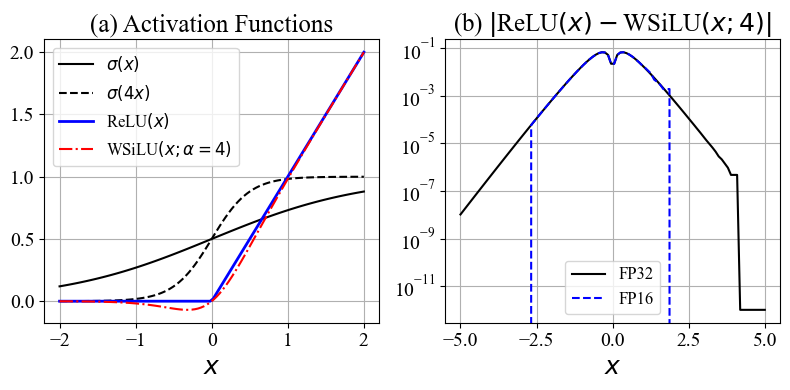

In [51]:
eps = 1e-12  # evita log(0) na segunda figura

plt.figure(figsize=(FIGURE_WIDTH, FIGURE_HEIGHT))
plt.rcParams["font.family"] = FONT_WINDOWS

# (a) Curvas das ativações
plt.subplot(1, 2, 1)
x = np.linspace(-2, 2, 100, dtype=np.float32)
plt.plot(x, sigmoid(x),           label="$\\sigma(x)$",        color="black")
plt.plot(x, sigmoid(4*x),         label="$\\sigma(4x)$",       color="black", linestyle="--")
plt.plot(x, relu(x),              label="ReLU$(x)$",           linewidth=2, color="blue")
plt.plot(x, wsilu(x, alpha=4.0),  label="WSiLU$(x; \\alpha=4)$", color="red", linestyle="-.")
plt.grid(True)
plt.legend(fontsize=LEGEND_FONT_SIZE)
plt.tick_params(axis='both', labelsize=TICK_FONT_SIZE)  # aumenta os ticks dos eixos
plt.xlabel("$x$", fontsize=LABELS_FONT_SIZE)
plt.title("(a) Activation Functions", fontsize=18)

# (b) Diferença |ReLU - WSiLU| em FP32 e FP16
plt.subplot(1, 2, 2)
x = np.linspace(-5, 5, 100, dtype=np.float32)

# FP32
diff_fp32 = np.abs(relu(x) - wsilu(x, alpha=4.0)) + eps

# FP16: faça o casting do input e dos resultados
x16 = x.astype(np.float16)
relu16 = relu(x16).astype(np.float16)
wsilu16 = wsilu(x16, alpha=4.0).astype(np.float16)
diff_fp16 = np.abs(relu16 - wsilu16).astype(np.float16) + eps

plt.plot(x, diff_fp32, label="FP32", color="black")
plt.plot(x, diff_fp16.astype(np.float32), label="FP16", linestyle="--", color="blue")

plt.yscale('log')
plt.grid(True)
plt.legend(fontsize=LEGEND_FONT_SIZE, loc="lower center")
plt.xlabel("$x$", fontsize=LABELS_FONT_SIZE)
plt.title("(b) $|$ReLU$(x)-$WSiLU$(x;4)|$", fontsize=TITLE_FONT_SIZE)
plt.tick_params(axis='both', labelsize=TICK_FONT_SIZE)  # aumenta os ticks dos eixos

plt.tight_layout()

plt.savefig(FIGURES_PATH + "/activation_func_error.pdf", dpi=1200, bbox_inches="tight")   # formato PNG


plt.show()


<Figure size 800x400 with 0 Axes>

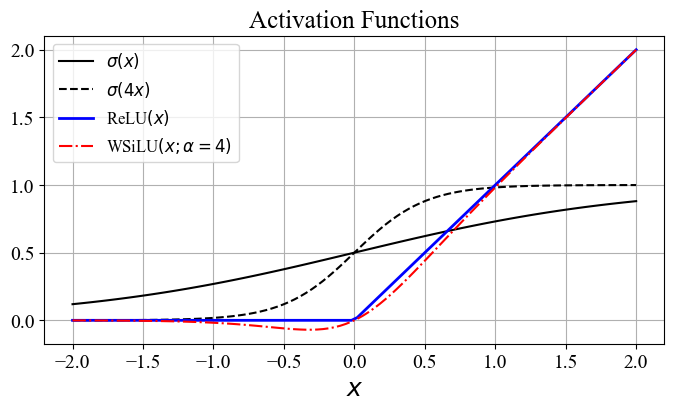

In [52]:


eps = 1e-12  # evita log(0) na segunda figura
plt.figure(figsize=(FIGURE_WIDTH, FIGURE_HEIGHT))
plt.figure(figsize=(FIGURE_WIDTH, FIGURE_HEIGHT))
plt.rcParams["font.family"] = FONT_WINDOWS


x = np.linspace(-2, 2, 100, dtype=np.float32)
plt.plot(x, sigmoid(x),           label="$\\sigma(x)$",        color="black")
plt.plot(x, sigmoid(4*x),         label="$\\sigma(4x)$",       color="black", linestyle="--")
plt.plot(x, relu(x),              label="ReLU$(x)$",           linewidth=2, color="blue")
plt.plot(x, wsilu(x, alpha=4.0),  label="WSiLU$(x; \\alpha=4)$", color="red", linestyle="-.")
plt.grid(True)
plt.legend(fontsize=LEGEND_FONT_SIZE)
plt.tick_params(axis='both', labelsize=TICK_FONT_SIZE)  # aumenta os ticks dos eixos
plt.xlabel("$x$", fontsize=LABELS_FONT_SIZE)
plt.title("Activation Functions", fontsize=18)
plt.savefig(FIGURES_PATH + "/activations_func_errorA.pdf", dpi=1200, bbox_inches="tight")   # formato PNG

C:\Users\Vanessa\AppData\Local\Temp\ipykernel_17316\335209942.py:2: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-x))


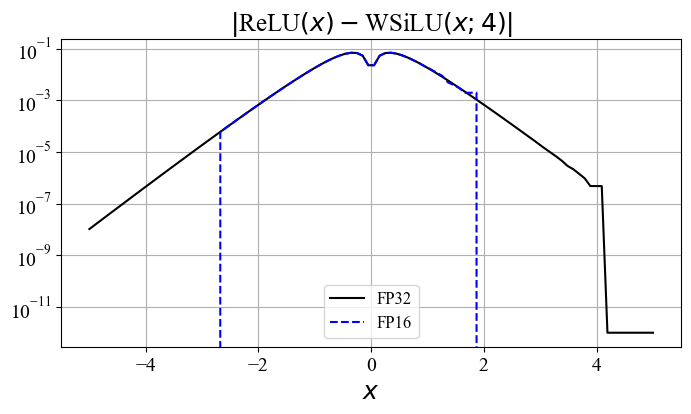

In [53]:
x = np.linspace(-5, 5, 100, dtype=np.float32)

# FP32
diff_fp32 = np.abs(relu(x) - wsilu(x, alpha=4.0)) + eps

# FP16: faça o casting do input e dos resultados
x16 = x.astype(np.float16)
relu16 = relu(x16).astype(np.float16)
wsilu16 = wsilu(x16, alpha=4.0).astype(np.float16)
diff_fp16 = np.abs(relu16 - wsilu16).astype(np.float16) + eps
plt.figure(figsize=(FIGURE_WIDTH, FIGURE_HEIGHT))
plt.plot(x, diff_fp32, label="FP32", color="black")
plt.plot(x, diff_fp16.astype(np.float32), label="FP16", linestyle="--", color="blue")

plt.yscale('log')
plt.grid(True)
plt.legend(fontsize=LEGEND_FONT_SIZE, loc="lower center")
plt.xlabel("$x$", fontsize=LABELS_FONT_SIZE)
plt.title("$|$ReLU$(x)-$WSiLU$(x;4)|$", fontsize=TITLE_FONT_SIZE)
plt.tick_params(axis='both', labelsize=TICK_FONT_SIZE)  # aumenta os ticks dos eixos
plt.savefig(FIGURES_PATH + "/abs_func_errorB.pdf", dpi=1200, bbox_inches="tight")   # formato PNG

plt.show()


### Aproximação de valores absolutos

C:\Users\Vanessa\AppData\Local\Temp\ipykernel_17316\335209942.py:11: RuntimeWarning: overflow encountered in exp
  return np.float16(x / (1.0 + np.exp(-4 * x)))


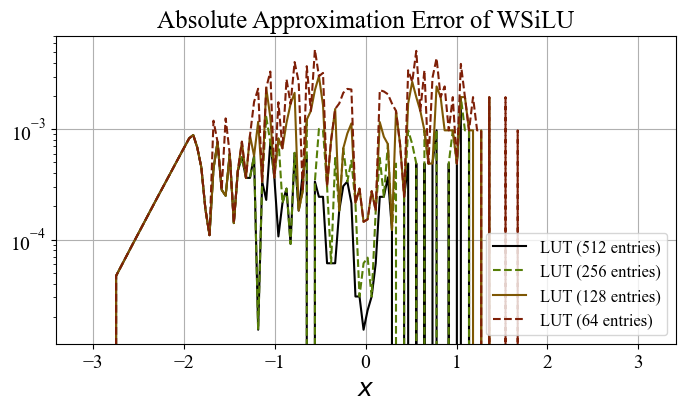

In [54]:

xs_sim = np.linspace(-3.1, 3.1, 140, dtype=np.float16)
ys_real_at_sim_points = wsilu_real(xs_sim)

# --- Error Calculation for LUT 64---
ys_sim_64 = np.array([wsilu_lut_64(val) for val in xs_sim])
error_64 = ys_real_at_sim_points - ys_sim_64

# --- Error Calculation for LUT 128 ---
ys_sim_128 = np.array([wsilu_lut_128(val) for val in xs_sim])
error_128 = ys_real_at_sim_points - ys_sim_128

# --- Error Calculation for LUT 256 ---
ys_sim_256 = np.array([wsilu_lut_256(val) for val in xs_sim])
error_256 = ys_real_at_sim_points - ys_sim_256

# --- Error Calculation for LUT 512 ---
ys_sim_512 = np.array([wsilu_lut_512(val) for val in xs_sim])
error_512 = ys_real_at_sim_points - ys_sim_512

# --- Error Calculation for Poly ---
ys_sim_poly = np.array([WSiLU_polinomial_float16_escalar(val) for val in xs_sim])
error_poly = abs(ys_real_at_sim_points - ys_sim_poly) + eps
plt.figure(figsize=(FIGURE_WIDTH, FIGURE_HEIGHT))
plt.rcParams["font.family"] = FONT_WINDOWS
plt.plot(xs_sim, abs(error_512), label="LUT (512 entries)", color="black", linestyle="-")
plt.plot(xs_sim, abs(error_256), label="LUT (256 entries)", color="#567E07", linestyle="--")
plt.plot(xs_sim, abs(error_128), label="LUT (128 entries)", color="#7e5704", linestyle="-")
plt.plot(xs_sim, abs(error_64), label="LUT (64 entries)", color="#7E1F07", linestyle="--")
#plt.plot(xs_sim, error_poly, label="Polynomial (degree 2)", color="black", linestyle="-")

plt.grid(True)
plt.legend(fontsize=LEGEND_FONT_SIZE, loc="best")
plt.tick_params(axis='both', labelsize=TICK_FONT_SIZE) 
plt.xlabel("$x$", fontsize=LABELS_FONT_SIZE)
plt.title("Absolute Approximation Error of WSiLU", fontsize=TITLE_FONT_SIZE)
plt.yscale('log')
plt.savefig(FIGURES_PATH + "/abs_appError_LUT.pdf", dpi=1200, bbox_inches="tight") 
plt.show()

C:\Users\Vanessa\AppData\Local\Temp\ipykernel_17316\335209942.py:11: RuntimeWarning: overflow encountered in exp
  return np.float16(x / (1.0 + np.exp(-4 * x)))


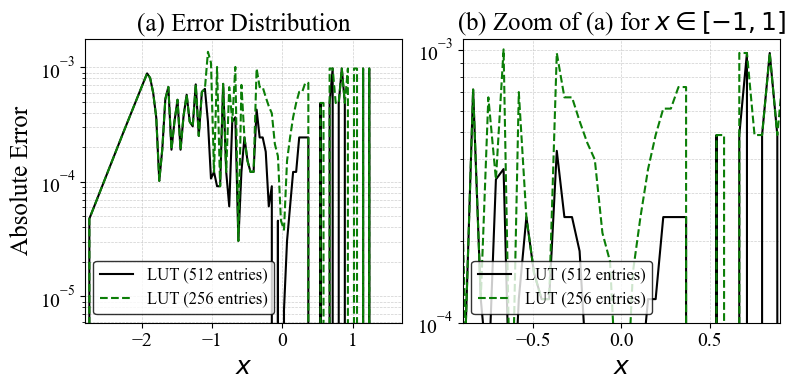

In [55]:
# --- Geração dos dados ---
xs_sim = np.linspace(-3, 3, 140, dtype=np.float16)
ys_real = wsilu_real(xs_sim)

# --- Cálculo dos erros ---
ys_sim_256 = np.array([wsilu_lut_256(val) for val in xs_sim])
ys_sim_512 = np.array([wsilu_lut_512(val) for val in xs_sim])

error_256 = np.abs(ys_real - ys_sim_256) + eps
error_512 = np.abs(ys_real - ys_sim_512) + eps

# --- Configuração global de estilo (IEEE-like) ---
plt.rcParams.update({
    "font.family": FONT_WINDOWS,
    "axes.titlesize": TITLE_FONT_SIZE,
    "axes.labelsize": LABELS_FONT_SIZE,
    "xtick.labelsize": TICK_FONT_SIZE,
    "ytick.labelsize": TICK_FONT_SIZE,
    "legend.fontsize": LEGEND_FONT_SIZE
})

# --- Figura ---
#fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
#fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(FIGURE_WIDTH, FIGURE_HEIGHT))


# (a) Curvas das ativações

# =========================
# (a) Global
# =========================

ax1.plot(xs_sim, error_512, label="LUT (512 entries)", color="black", linewidth=1.5)
ax1.plot(xs_sim, error_256, label="LUT (256 entries)", color="#0B7E07", linestyle="--", linewidth=1.5)

ax1.set_yscale('log')
ax1.set_xlim(-2.8, 1.7)

ax1.set_xlabel(r"$x$")
ax1.set_ylabel(r"Absolute Error")
ax1.set_title(r"(a) Error Distribution")

ax1.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.6)
ax1.legend(loc="lower left", frameon=True, edgecolor="black")

# =========================
# (b) Zoom

ax2.plot(xs_sim, error_512, label="LUT (512 entries)", color="black", linewidth=1.5)
ax2.plot(xs_sim, error_256, label="LUT (256 entries)", color="#0B7E07", linestyle="--", linewidth=1.5)

ax2.set_yscale('log')
ax2.set_xlim(-0.9, 0.9)
ax2.set_ylim(1e-4,1.1e-3)


ax2.set_xlabel(r"$x$")
ax2.set_title(r"(b) Zoom of (a) for $x \in [-1, 1]$")

ax2.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.6)
ax2.legend(loc="lower left", frameon=True, edgecolor="black")

# --- Layout e exportação ---
plt.tight_layout()
plt.savefig(FIGURES_PATH + "/abs_appError_AB_LUT.pdf", dpi=1200, bbox_inches="tight")
plt.show()

C:\Users\Vanessa\AppData\Local\Temp\ipykernel_17316\335209942.py:11: RuntimeWarning: overflow encountered in exp
  return np.float16(x / (1.0 + np.exp(-4 * x)))


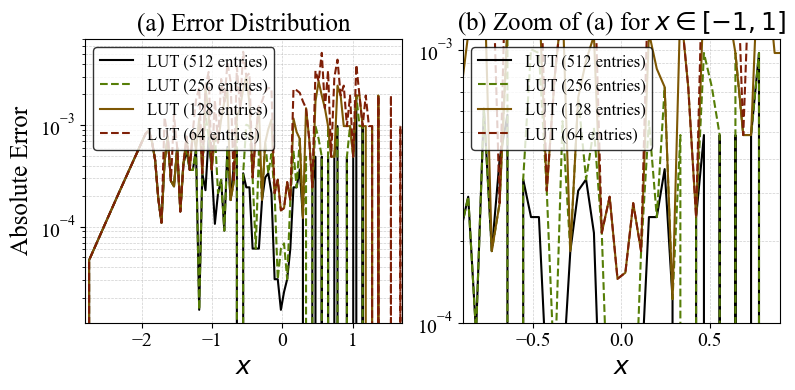

In [56]:

xs_sim = np.linspace(-3.1, 3.1, 140, dtype=np.float16)
ys_real_at_sim_points = wsilu_real(xs_sim)

# --- Error Calculation for LUT 64---
ys_sim_64 = np.array([wsilu_lut_64(val) for val in xs_sim])
error_64 = ys_real_at_sim_points - ys_sim_64

# --- Error Calculation for LUT 128 ---
ys_sim_128 = np.array([wsilu_lut_128(val) for val in xs_sim])
error_128 = ys_real_at_sim_points - ys_sim_128

# --- Error Calculation for LUT 256 ---
ys_sim_256 = np.array([wsilu_lut_256(val) for val in xs_sim])
error_256 = ys_real_at_sim_points - ys_sim_256

# --- Error Calculation for LUT 512 ---
ys_sim_512 = np.array([wsilu_lut_512(val) for val in xs_sim])
error_512 = ys_real_at_sim_points - ys_sim_512

# --- Error Calculation for Poly ---
ys_sim_poly = np.array([WSiLU_polinomial_float16_escalar(val) for val in xs_sim])
error_poly = abs(ys_real_at_sim_points - ys_sim_poly) + eps

# --- Figura ---
#fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
#fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(FIGURE_WIDTH, FIGURE_HEIGHT))


ax1.plot(xs_sim, abs(error_512), label="LUT (512 entries)", color="black", linestyle="-")
ax1.plot(xs_sim, abs(error_256), label="LUT (256 entries)", color="#567E07", linestyle="--")
ax1.plot(xs_sim, abs(error_128), label="LUT (128 entries)", color="#7e5704", linestyle="-")
ax1.plot(xs_sim, abs(error_64), label="LUT (64 entries)", color="#7E1F07", linestyle="--")


ax1.set_yscale('log')
ax1.set_xlim(-2.8, 1.7)

ax1.set_xlabel(r"$x$")
ax1.set_ylabel(r"Absolute Error")
ax1.set_title(r"(a) Error Distribution")

ax1.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.6)
ax1.legend(loc="upper left", frameon=True, edgecolor="black")

# =========================
# (b) Zoom

ax2.plot(xs_sim, abs(error_512), label="LUT (512 entries)", color="black", linestyle="-")
ax2.plot(xs_sim, abs(error_256), label="LUT (256 entries)", color="#567E07", linestyle="--")
ax2.plot(xs_sim, abs(error_128), label="LUT (128 entries)", color="#7e5704", linestyle="-")
ax2.plot(xs_sim, abs(error_64), label="LUT (64 entries)", color="#7E1F07", linestyle="--")

ax2.set_yscale('log')
ax2.set_xlim(-0.9, 0.9)
ax2.set_ylim(1e-4,1.1e-3)


ax2.set_xlabel(r"$x$")
ax2.set_title(r"(b) Zoom of (a) for $x \in [-1, 1]$")

ax2.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.6)
ax2.legend(loc="upper left", frameon=True, edgecolor="black")

# --- Layout e exportação ---
plt.tight_layout()

plt.savefig(FIGURES_PATH + "/abs_appError_AB_LUTS.pdf", dpi=1200, bbox_inches="tight")
plt.show()

C:\Users\Vanessa\AppData\Local\Temp\ipykernel_17316\335209942.py:11: RuntimeWarning: overflow encountered in exp
  return np.float16(x / (1.0 + np.exp(-4 * x)))


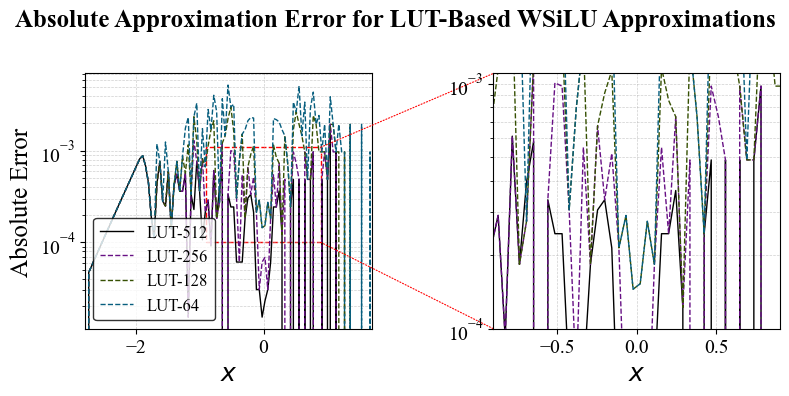

In [57]:

xs_sim = np.linspace(-3.1, 3.1, 140, dtype=np.float16)
ys_real_at_sim_points = wsilu_real(xs_sim)

# LUT-64
ys_sim_64 = np.array([wsilu_lut_64(val) for val in xs_sim])
error_64 = np.abs(ys_real_at_sim_points - ys_sim_64) + eps

# LUT-128
ys_sim_128 = np.array([wsilu_lut_128(val) for val in xs_sim])
error_128 = np.abs(ys_real_at_sim_points - ys_sim_128) + eps

# LUT-256
ys_sim_256 = np.array([wsilu_lut_256(val) for val in xs_sim])
error_256 = np.abs(ys_real_at_sim_points - ys_sim_256) + eps

# LUT-512
ys_sim_512 = np.array([wsilu_lut_512(val) for val in xs_sim])
error_512 = np.abs(ys_real_at_sim_points - ys_sim_512) + eps

zoom_x1, zoom_x2 = -0.9, 0.9
zoom_y1, zoom_y2 = 1e-4, 1.1e-3


fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(FIGURE_WIDTH, FIGURE_HEIGHT)
    #,gridspec_kw={'width_ratios': [1.2, 1]}
)


ax1.plot(
    xs_sim,
    error_512,
    label="LUT-512",
    color="black",
    linestyle="-",
    linewidth=1
)

ax1.plot(
    xs_sim,
    error_256,
    label="LUT-256",
    color="#671084",
    linestyle="--",
    linewidth=1
)

ax1.plot(
    xs_sim,
    error_128,
    label="LUT-128",
    color="#365003",
    linestyle="--",
    linewidth=1
)

ax1.plot(
    xs_sim,
    error_64,
    label="LUT-64",
    color="#075E7E",
    linestyle="--",
    linewidth=1
)

ax1.set_yscale('log')
ax1.set_xlim(-2.8, 1.7)

ax1.set_xlabel(r"$x$")
ax1.set_ylabel(r"Absolute Error")

ax1.grid(
    True,
    which="both",
    linestyle="--",
    linewidth=0.5,
    alpha=0.6
)

ax1.legend(
    loc="lower left",
    frameon=True,
    edgecolor="black"
)


rect = Rectangle(
    (zoom_x1, zoom_y1),
    zoom_x2 - zoom_x1,
    zoom_y2 - zoom_y1,
    linewidth=1.0,
    edgecolor="red",
    linestyle="--",
    facecolor="none"
)

ax1.add_patch(rect)

ax2.plot(
    xs_sim,
    error_512,
    color="black",
    linestyle="-",
    linewidth=1
)

ax2.plot(
    xs_sim,
    error_256,
    color="#671084",
    linestyle="--",
    linewidth=1
)

ax2.plot(
    xs_sim,
    error_128,
    color="#365003",
    linestyle="--",
    linewidth=1
)

ax2.plot(
    xs_sim,
    error_64,
    color="#075E7E",
    linestyle="--",
    linewidth=1
)

ax2.set_yscale('log')

ax2.set_xlim(zoom_x1, zoom_x2)
ax2.set_ylim(zoom_y1, zoom_y2)

ax2.set_xlabel(r"$x$")

ax2.grid(
    True,
    which="both",
    linestyle="--",
    linewidth=0.5,
    alpha=0.6
)

con1 = ConnectionPatch(
    xyA=(zoom_x2, zoom_y2),
    xyB=(zoom_x1, zoom_y2),
    coordsA="data",
    coordsB="data",
    axesA=ax1,
    axesB=ax2,
    linestyle=":",
    linewidth=0.8,
    color="red"
)

con2 = ConnectionPatch(
    xyA=(zoom_x2, zoom_y1),
    xyB=(zoom_x1, zoom_y1),
    coordsA="data",
    coordsB="data",
    axesA=ax1,
    axesB=ax2,
    linestyle=":",
    linewidth=0.8,
    color="red"
)

ax2.add_artist(con1)
ax2.add_artist(con2)

fig.suptitle(
    "Absolute Approximation Error for LUT-Based WSiLU Approximations",
    fontsize=TITLE_FONT_SIZE,
    weight="bold",
    y=0.98
)


plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(
    FIGURES_PATH + "/abs_appError_AB_LUTS.pdf",
    dpi=1200,
    bbox_inches="tight"
)

plt.show()

C:\Users\Vanessa\AppData\Local\Temp\ipykernel_17316\335209942.py:11: RuntimeWarning: overflow encountered in exp
  return np.float16(x / (1.0 + np.exp(-4 * x)))


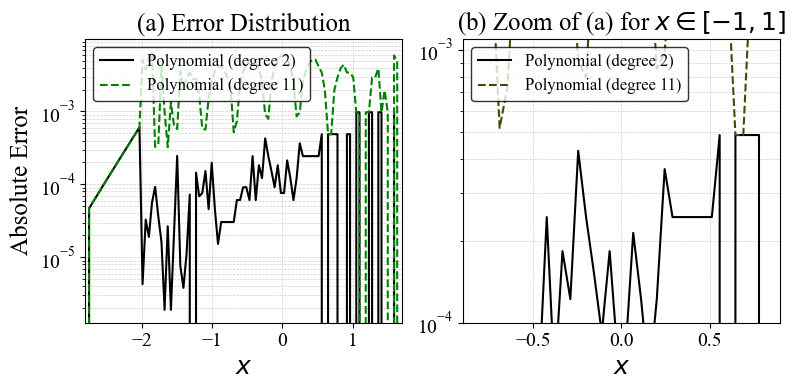

In [58]:
xs_sim = np.linspace(-3.1, 3.1, 140, dtype=np.float16)
ys_real_at_sim_points = wsilu_real(xs_sim)


# --- Error Calculation for Poly ---
ys_sim_poly = np.array([WSiLU_polinomial_float16_escalar(val) for val in xs_sim])
error_poly = abs(ys_real_at_sim_points - ys_sim_poly) + eps


ys_sim_poly11 = np.array([WSiLU_poly11(val) for val in xs_sim])
error_poly11 = abs(ys_real_at_sim_points - ys_sim_poly11) + eps

# --- Figura ---
#fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
#fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(FIGURE_WIDTH, FIGURE_HEIGHT))


ax1.plot(xs_sim, error_poly, label="Polynomial (degree 2)", color="black", linestyle="-")
ax1.plot(xs_sim, error_poly11, label="Polynomial (degree 11)", color="green", linestyle="--")


ax1.set_yscale('log')
ax1.set_xlim(-2.8, 1.7)

ax1.set_xlabel(r"$x$")
ax1.set_ylabel(r"Absolute Error")
ax1.set_title(r"(a) Error Distribution")

ax1.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.6)
ax1.legend(loc="upper left", frameon=True, edgecolor="black")

# =========================
# (b) Zoom


ax2.plot(xs_sim, error_poly, label="Polynomial (degree 2)", color="black", linestyle="-")
ax2.plot(xs_sim, error_poly11, label="Polynomial (degree 11)",     color="#365003", linestyle="--")

ax2.set_yscale('log')
ax2.set_xlim(-0.9, 0.9)
ax2.set_ylim(1e-4,1.1e-3)


ax2.set_xlabel(r"$x$")
ax2.set_title(r"(b) Zoom of (a) for $x \in [-1, 1]$")

ax2.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.6)
ax2.legend(loc="upper left", frameon=True, edgecolor="black")

# --- Layout e exportação ---
plt.tight_layout()
plt.savefig(FIGURES_PATH + "/abs_appError_AB_POL.pdf", dpi=1200, bbox_inches="tight")
plt.show()

C:\Users\Vanessa\AppData\Local\Temp\ipykernel_17316\335209942.py:11: RuntimeWarning: overflow encountered in exp
  return np.float16(x / (1.0 + np.exp(-4 * x)))


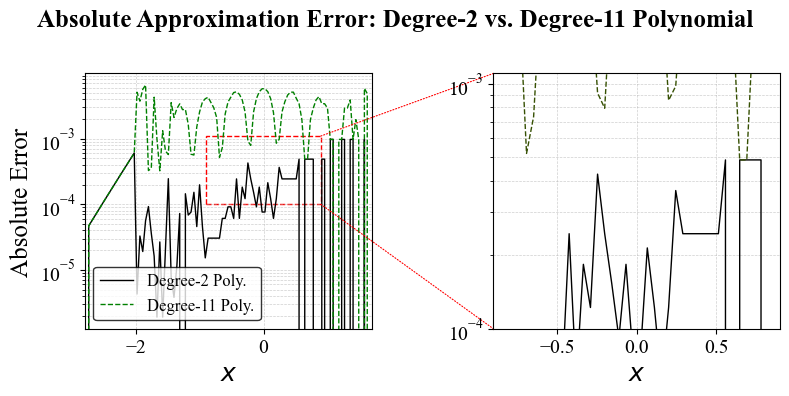

In [59]:

xs_sim = np.linspace(-3.1, 3.1, 140, dtype=np.float16)
ys_real_at_sim_points = wsilu_real(xs_sim)

ys_sim_poly = np.array(
    [WSiLU_polinomial_float16_escalar(val) for val in xs_sim]
)
error_poly = np.abs(ys_real_at_sim_points - ys_sim_poly) + eps

ys_sim_poly11 = np.array(
    [WSiLU_poly11(val) for val in xs_sim]
)
error_poly11 = np.abs(ys_real_at_sim_points - ys_sim_poly11) + eps


zoom_x1, zoom_x2 = -0.9, 0.9
zoom_y1, zoom_y2 = 1e-4, 1.1e-3


fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(FIGURE_WIDTH, FIGURE_HEIGHT)
)

ax1.plot(
    xs_sim,
    error_poly,
    label="Degree-2 Poly.",
    color="black",
    linestyle="-",
    linewidth=1
)

ax1.plot(
    xs_sim,
    error_poly11,
    label="Degree-11 Poly.",
    color="green",
    linestyle="--",
    linewidth=1
)

ax1.set_yscale('log')
ax1.set_xlim(-2.8, 1.7)

ax1.set_xlabel(r"$x$")
ax1.set_ylabel(r"Absolute Error")

ax1.grid(
    True,
    which="both",
    linestyle="--",
    linewidth=0.5,
    alpha=0.6
)

ax1.legend(
    loc="lower left",
    frameon=True,
    edgecolor="black"
)

rect = Rectangle(
    (zoom_x1, zoom_y1),
    zoom_x2 - zoom_x1,
    zoom_y2 - zoom_y1,
    linewidth=1.0,
    edgecolor="red",
    linestyle="--",
    facecolor="none"
)

ax1.add_patch(rect)

ax2.plot(
    xs_sim,
    error_poly,
    color="black",
    linestyle="-",
    linewidth=1
)

ax2.plot(
    xs_sim,
    error_poly11,
    color="#365003",
    linestyle="--",
    linewidth=1
)

ax2.set_yscale('log')

ax2.set_xlim(zoom_x1, zoom_x2)
ax2.set_ylim(zoom_y1, zoom_y2)

ax2.set_xlabel(r"$x$")


ax2.grid(
    True,
    which="both",
    linestyle="--",
    linewidth=0.5,
    alpha=0.6
)


con1 = ConnectionPatch(
    xyA=(zoom_x2, zoom_y2),
    xyB=(zoom_x1, zoom_y2),
    coordsA="data",
    coordsB="data",
    axesA=ax1,
    axesB=ax2,
    linestyle=":",
    linewidth=0.8,
    color="red"
)

con2 = ConnectionPatch(
    xyA=(zoom_x2, zoom_y1),
    xyB=(zoom_x1, zoom_y1),
    coordsA="data",
    coordsB="data",
    axesA=ax1,
    axesB=ax2,
    linestyle=":",
    linewidth=0.8,
    color="red"
)

ax2.add_artist(con1)
ax2.add_artist(con2)

fig.suptitle(
    "Absolute Approximation Error: Degree-2 vs. Degree-11 Polynomial",
    fontsize=TITLE_FONT_SIZE,
    weight="bold",
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(
    FIGURES_PATH + "/abs_appError_AB_POL.pdf",
    dpi=1200,
    bbox_inches="tight"
)

plt.show()

### WSiLU real vs WSiLU aproximada

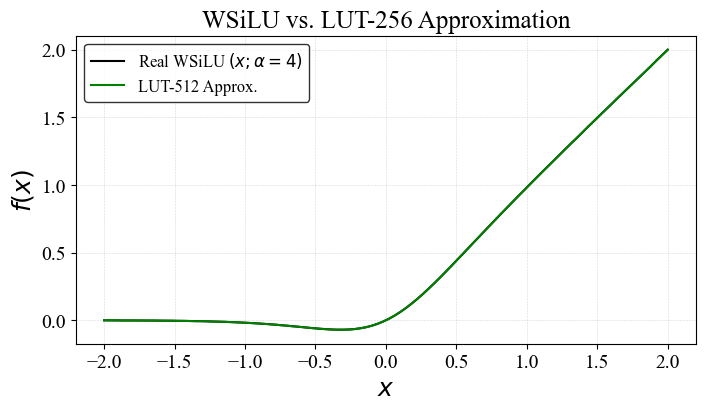

In [60]:

eps = 1e-12  

plt.figure(figsize=(FIGURE_WIDTH, FIGURE_HEIGHT))
plt.rcParams["font.family"] = FONT_WINDOWS

x = np.linspace(-2, 2, 100, dtype=np.float16)

plt.plot(x, wsilu(x, alpha=4.0), label=r"Real WSiLU $(x; \alpha=4)$", color="black", linestyle="-", linewidth=1.5)

ys_lut_512 = np.array([wsilu_lut_512(val) for val in x])
plt.plot(x, ys_lut_512, label=r"LUT-512 Approx.", color="green", linestyle="-", linewidth=1.5)

#ys_lut_256 = np.array([wsilu_lut_256(val) for val in x])
#plt.plot(x, ys_lut_256, label=r"LUT-256 Approx.", color="red", linestyle="--", linewidth=1.5)

#ys_lut_128 = np.array([wsilu_lut_128(val) for val in x])
#plt.plot(x, ys_lut_128, label=r"LUT-128 Approx.", color="red", linestyle="--", linewidth=1.5)


#ys_lut_64 = np.array([wsilu_lut_64(val) for val in x])
#plt.plot(x, ys_lut_64, label=r"LUT-64 Approx.", color="green", linestyle="-", linewidth=1.5)


# --- Configurações de Gráfico Acadêmico ---
plt.grid(True, which="both", linestyle="--", linewidth=0.4, alpha=0.5)
plt.legend(fontsize=LEGEND_FONT_SIZE, loc="best", frameon=True, edgecolor="black")
plt.tick_params(axis='both', labelsize=TICK_FONT_SIZE)  

plt.xlabel("$x$", fontsize=LABELS_FONT_SIZE)
plt.ylabel("$f(x)$", fontsize=LABELS_FONT_SIZE)
plt.title("WSiLU vs. LUT-256 Approximation", fontsize=TITLE_FONT_SIZE)

# Salvamento direto no caminho de figuras do paper
plt.savefig(FIGURES_PATH + "/real_vs_appr.pdf", dpi=1200, bbox_inches="tight")  

plt.show()

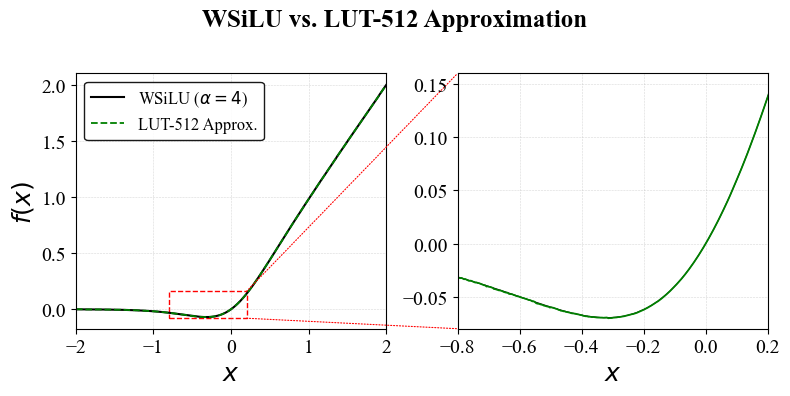

In [61]:
# 1000 pontos garante definição perfeita na curva do zoom
x = np.linspace(-2, 2, 1000, dtype=np.float16)

ys_real = wsilu_real(x)
ys_lut_512 = np.array([wsilu_lut_512(val) for val in x])

zoom_x1, zoom_x2 = -0.8, 0.2
zoom_y1, zoom_y2 = -0.08, 0.16

plt.rcParams.update({
    "font.family": FONT_WINDOWS,
    "axes.labelsize": LABELS_FONT_SIZE,
    "xtick.labelsize": TICK_FONT_SIZE,
    "ytick.labelsize": TICK_FONT_SIZE,
    "legend.fontsize": LEGEND_FONT_SIZE
})

# --- Inicialização da Figura com 2 Subplots (Lado a Lado) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(FIGURE_WIDTH, FIGURE_HEIGHT))


ax1.plot(x, ys_real, label=r"WSiLU ($\alpha=4$)", color="black", linestyle="-", linewidth=1.5)
ax1.plot(x, ys_lut_512, label=r"LUT-512 Approx.", color="green", linestyle="--", linewidth=1.3)

ax1.set_xlim(-2, 2)
ax1.set_xlabel("$x$")
ax1.set_ylabel("$f(x)$")
ax1.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)
ax1.legend(loc="upper left", frameon=True, edgecolor="black", framealpha=0.9)

# Adiciona o retângulo tracejado indicando a região do zoom em ax1
rect = Rectangle(
    (zoom_x1, zoom_y1),
    zoom_x2 - zoom_x1,
    zoom_y2 - zoom_y1,
    linewidth=1.0,
    edgecolor='red',
    linestyle='--',
    facecolor='none'
)
ax1.add_patch(rect)


ax2.plot(x, ys_real, color="black", linestyle="-", linewidth=0.8)
ax2.plot(x, ys_lut_512, color="green", linestyle="-", linewidth=1.3)

# Trava os eixos estritamente na região do retângulo
ax2.set_xlim(zoom_x1, zoom_x2)
ax2.set_ylim(zoom_y1, zoom_y2)

ax2.set_xlabel("$x$")
ax2.grid(True, which="both", linestyle="--", linewidth=0.4, alpha=0.5)

con1 = ConnectionPatch(xyA=(zoom_x2, zoom_y2), xyB=(zoom_x1, zoom_y2), 
                        coordsA="data", coordsB="data",
                        axesA=ax1, axesB=ax2, 
                        linestyle=":", linewidth=0.8, color="red")

con2 = ConnectionPatch(xyA=(zoom_x2, zoom_y1), xyB=(zoom_x1, zoom_y1), 
                        coordsA="data", coordsB="data",
                        axesA=ax1, axesB=ax2, 
                        linestyle=":", linewidth=0.8, color="red")

ax2.add_artist(con1)
ax2.add_artist(con2)
fig.subplots_adjust(wspace=0.0)

fig.suptitle("WSiLU vs. LUT-512 Approximation", 
             fontsize=TITLE_FONT_SIZE, weight='bold', y=0.98)


plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.subplots_adjust(wspace=0.23)
plt.savefig(FIGURES_PATH + "/real_vs_appr_zoom512.pdf", dpi=1200, bbox_inches="tight")
plt.show()

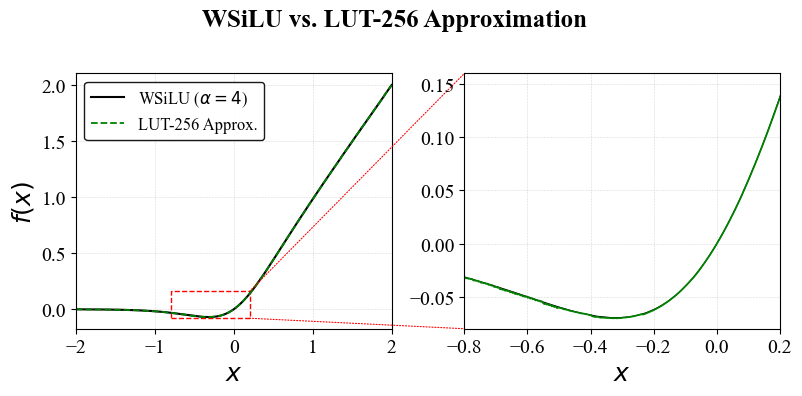

In [62]:

x = np.linspace(-2, 2, 1000, dtype=np.float16)


ys_real = wsilu_real(x)
ys_lut_256 = np.array([wsilu_lut_256(val) for val in x])

# --- Definição da Região do Super Zoom ---
zoom_x1, zoom_x2 = -0.8, 0.2
zoom_y1, zoom_y2 = -0.08, 0.16

plt.rcParams.update({
    "font.family": FONT_WINDOWS,
    "axes.labelsize": LABELS_FONT_SIZE,
    "xtick.labelsize": TICK_FONT_SIZE,
    "ytick.labelsize": TICK_FONT_SIZE,
    "legend.fontsize": LEGEND_FONT_SIZE
})


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(FIGURE_WIDTH, FIGURE_HEIGHT))


ax1.plot(x, ys_real, label=r"WSiLU ($\alpha=4$)", color="black", linestyle="-", linewidth=1.5)
ax1.plot(x, ys_lut_256, label=r"LUT-256 Approx.", color="green", linestyle="--", linewidth=1.3)

ax1.set_xlim(-2, 2)
ax1.set_xlabel("$x$")
ax1.set_ylabel("$f(x)$")
ax1.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)
ax1.legend(loc="upper left", frameon=True, edgecolor="black", framealpha=0.9)

# Adiciona o retângulo 
rect = Rectangle(
    (zoom_x1, zoom_y1),
    zoom_x2 - zoom_x1,
    zoom_y2 - zoom_y1,
    linewidth=1.0,
    edgecolor='red',
    linestyle='--',
    facecolor='none'
)
ax1.add_patch(rect)

# ============
# Super Zoom 
# ============
ax2.plot(x, ys_real, color="black", linestyle="-", linewidth=0.8)
ax2.plot(x, ys_lut_256, color="green", linestyle="-", linewidth=1.3)

# Trava os eixos estritamente na região do retângulo
ax2.set_xlim(zoom_x1, zoom_x2)
ax2.set_ylim(zoom_y1, zoom_y2)

ax2.set_xlabel("$x$")
ax2.grid(True, which="both", linestyle="--", linewidth=0.4, alpha=0.5)


con1 = ConnectionPatch(xyA=(zoom_x2, zoom_y2), xyB=(zoom_x1, zoom_y2), 
                        coordsA="data", coordsB="data",
                        axesA=ax1, axesB=ax2, 
                        linestyle=":", linewidth=0.8, color="red")

con2 = ConnectionPatch(xyA=(zoom_x2, zoom_y1), xyB=(zoom_x1, zoom_y1), 
                        coordsA="data", coordsB="data",
                        axesA=ax1, axesB=ax2, 
                        linestyle=":", linewidth=0.8, color="red")

ax2.add_artist(con1)
ax2.add_artist(con2)

fig.suptitle("WSiLU vs. LUT-256 Approximation", 
             fontsize=TITLE_FONT_SIZE, weight='bold', y=0.98)


plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.subplots_adjust(wspace=0.23)
plt.savefig(FIGURES_PATH + "/real_vs_appr_zoom256.pdf", dpi=1200, bbox_inches="tight")
plt.show()

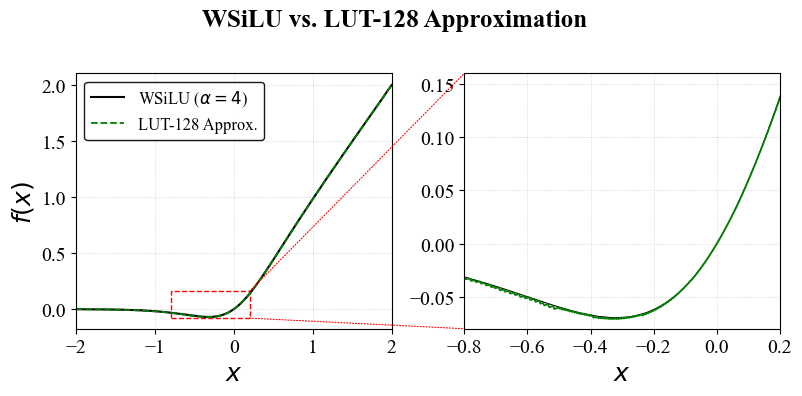

In [63]:

x = np.linspace(-2, 2, 1000, dtype=np.float16)


ys_real = wsilu_real(x)
ys_lut_128 = np.array([wsilu_lut_128(val) for val in x])

# --- Definição da Região do Super Zoom ---
zoom_x1, zoom_x2 = -0.8, 0.2
zoom_y1, zoom_y2 = -0.08, 0.16

plt.rcParams.update({
    "font.family": FONT_WINDOWS,
    "axes.labelsize": LABELS_FONT_SIZE,
    "xtick.labelsize": TICK_FONT_SIZE,
    "ytick.labelsize": TICK_FONT_SIZE,
    "legend.fontsize": LEGEND_FONT_SIZE
})


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(FIGURE_WIDTH, FIGURE_HEIGHT))


ax1.plot(x, ys_real, label=r"WSiLU ($\alpha=4$)", color="black", linestyle="-", linewidth=1.5)
ax1.plot(x, ys_lut_128, label=r"LUT-128 Approx.", color="green", linestyle="--", linewidth=1.3)

ax1.set_xlim(-2, 2)
ax1.set_xlabel("$x$")
ax1.set_ylabel("$f(x)$")
ax1.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)
ax1.legend(loc="upper left", frameon=True, edgecolor="black", framealpha=0.9)

# Adiciona o retângulo 
rect = Rectangle(
    (zoom_x1, zoom_y1),
    zoom_x2 - zoom_x1,
    zoom_y2 - zoom_y1,
    linewidth=1.0,
    edgecolor='red',
    linestyle='--',
    facecolor='none'
)
ax1.add_patch(rect)

# ============
# Super Zoom 
# ============
ax2.plot(x, ys_real, color="black", linestyle="-", linewidth=0.8)
ax2.plot(x, ys_lut_128, color="green", linestyle="-", linewidth=1.3)

# Trava os eixos estritamente na região do retângulo
ax2.set_xlim(zoom_x1, zoom_x2)
ax2.set_ylim(zoom_y1, zoom_y2)

ax2.set_xlabel("$x$")
ax2.grid(True, which="both", linestyle="--", linewidth=0.4, alpha=0.5)


con1 = ConnectionPatch(xyA=(zoom_x2, zoom_y2), xyB=(zoom_x1, zoom_y2), 
                        coordsA="data", coordsB="data",
                        axesA=ax1, axesB=ax2, 
                        linestyle=":", linewidth=0.8, color="red")

con2 = ConnectionPatch(xyA=(zoom_x2, zoom_y1), xyB=(zoom_x1, zoom_y1), 
                        coordsA="data", coordsB="data",
                        axesA=ax1, axesB=ax2, 
                        linestyle=":", linewidth=0.8, color="red")

ax2.add_artist(con1)
ax2.add_artist(con2)

fig.suptitle("WSiLU vs. LUT-128 Approximation", 
             fontsize=TITLE_FONT_SIZE, weight='bold', y=0.98)


plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.subplots_adjust(wspace=0.23)
plt.savefig(FIGURES_PATH + "/real_vs_appr_zoom128.pdf", dpi=1200, bbox_inches="tight")
plt.show()

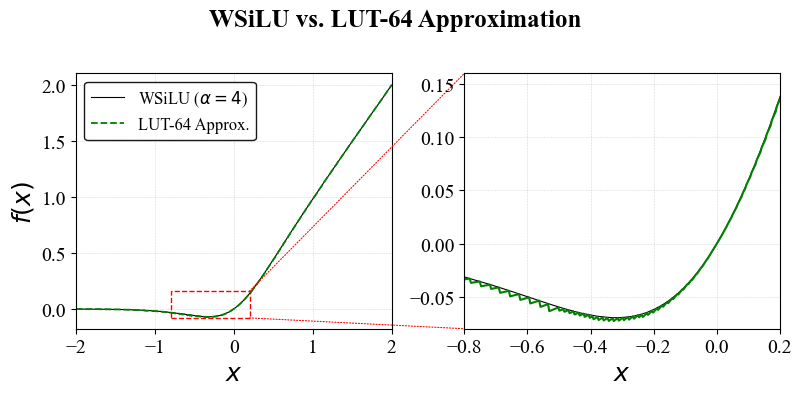

In [64]:

x = np.linspace(-2, 2, 1000, dtype=np.float16)


ys_real = wsilu_real(x)
ys_lut_64 = np.array([wsilu_lut_64(val) for val in x])

# --- Definição da Região do Super Zoom ---
zoom_x1, zoom_x2 = -0.8, 0.2
zoom_y1, zoom_y2 = -0.08, 0.16

plt.rcParams.update({
    "font.family": FONT_WINDOWS,
    "axes.labelsize": LABELS_FONT_SIZE,
    "xtick.labelsize": TICK_FONT_SIZE,
    "ytick.labelsize": TICK_FONT_SIZE,
    "legend.fontsize": LEGEND_FONT_SIZE
})


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(FIGURE_WIDTH, FIGURE_HEIGHT))


ax1.plot(x, ys_real, label=r"WSiLU ($\alpha=4$)", color="black", linestyle="-", linewidth=0.8)
ax1.plot(x, ys_lut_64, label=r"LUT-64 Approx.", color="green", linestyle="--", linewidth=1.3)

ax1.set_xlim(-2, 2)
ax1.set_xlabel("$x$")
ax1.set_ylabel("$f(x)$")
ax1.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)
ax1.legend(loc="upper left", frameon=True, edgecolor="black", framealpha=0.9)

# Adiciona o retângulo 
rect = Rectangle(
    (zoom_x1, zoom_y1),
    zoom_x2 - zoom_x1,
    zoom_y2 - zoom_y1,
    linewidth=1.0,
    edgecolor='red',
    linestyle='--',
    facecolor='none'
)
ax1.add_patch(rect)

# ============
# Super Zoom 
# ============
ax2.plot(x, ys_real, color="black", linestyle="-", linewidth=0.8)
ax2.plot(x, ys_lut_64, color="green", linestyle="-",  linewidth=1.5)

# Trava os eixos estritamente na região do retângulo
ax2.set_xlim(zoom_x1, zoom_x2)
ax2.set_ylim(zoom_y1, zoom_y2)

ax2.set_xlabel("$x$")
ax2.grid(True, which="both", linestyle="--", linewidth=0.4, alpha=0.5)


con1 = ConnectionPatch(xyA=(zoom_x2, zoom_y2), xyB=(zoom_x1, zoom_y2), 
                        coordsA="data", coordsB="data",
                        axesA=ax1, axesB=ax2, 
                        linestyle=":", linewidth=0.8, color="red")

con2 = ConnectionPatch(xyA=(zoom_x2, zoom_y1), xyB=(zoom_x1, zoom_y1), 
                        coordsA="data", coordsB="data",
                        axesA=ax1, axesB=ax2, 
                        linestyle=":", linewidth=0.8, color="red")

ax2.add_artist(con1)
ax2.add_artist(con2)

fig.suptitle("WSiLU vs. LUT-64 Approximation", 
             fontsize=TITLE_FONT_SIZE, weight='bold', y=0.98)


plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.subplots_adjust(wspace=0.23)
plt.savefig(FIGURES_PATH + "/real_vs_appr_zoom64.pdf", dpi=1200, bbox_inches="tight")
plt.show()

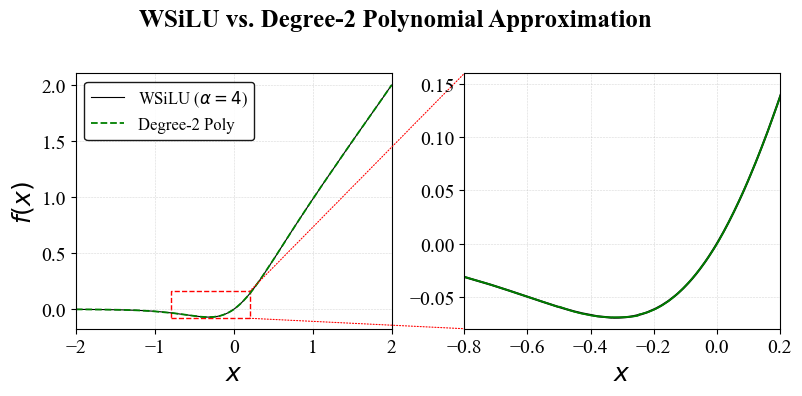

In [65]:

x = np.linspace(-2, 2, 1000, dtype=np.float16)


ys_real = wsilu_real(x)
ys_lut_pol2 = np.array([WSiLU_polinomial_float16_escalar(val) for val in x])

# --- Definição da Região do Super Zoom ---
zoom_x1, zoom_x2 = -0.8, 0.2
zoom_y1, zoom_y2 = -0.08, 0.16

plt.rcParams.update({
    "font.family": FONT_WINDOWS,
    "axes.labelsize": LABELS_FONT_SIZE,
    "xtick.labelsize": TICK_FONT_SIZE,
    "ytick.labelsize": TICK_FONT_SIZE,
    "legend.fontsize": LEGEND_FONT_SIZE
})


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(FIGURE_WIDTH, FIGURE_HEIGHT))


ax1.plot(x, ys_real, label=r"WSiLU ($\alpha=4$)", color="black", linestyle="-", linewidth=0.8)
ax1.plot(x, ys_lut_pol2, label=r"Degree-2 Poly", color="green", linestyle="--", linewidth=1.3)

ax1.set_xlim(-2, 2)
ax1.set_xlabel("$x$")
ax1.set_ylabel("$f(x)$")
ax1.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)
ax1.legend(loc="upper left", frameon=True, edgecolor="black", framealpha=0.9)

# Adiciona o retângulo 
rect = Rectangle(
    (zoom_x1, zoom_y1),
    zoom_x2 - zoom_x1,
    zoom_y2 - zoom_y1,
    linewidth=1.0,
    edgecolor='red',
    linestyle='--',
    facecolor='none'
)
ax1.add_patch(rect)

# ============
# Super Zoom 
# ============
ax2.plot(x, ys_real, color="black", linestyle="-", linewidth=1.5)
ax2.plot(x, ys_lut_pol2, color="green", linestyle="-", linewidth=1.3)

# Trava os eixos estritamente na região do retângulo
ax2.set_xlim(zoom_x1, zoom_x2)
ax2.set_ylim(zoom_y1, zoom_y2)

ax2.set_xlabel("$x$")
ax2.grid(True, which="both", linestyle="--", linewidth=0.4, alpha=0.5)


con1 = ConnectionPatch(xyA=(zoom_x2, zoom_y2), xyB=(zoom_x1, zoom_y2), 
                        coordsA="data", coordsB="data",
                        axesA=ax1, axesB=ax2, 
                        linestyle=":", linewidth=0.8, color="red")

con2 = ConnectionPatch(xyA=(zoom_x2, zoom_y1), xyB=(zoom_x1, zoom_y1), 
                        coordsA="data", coordsB="data",
                        axesA=ax1, axesB=ax2, 
                        linestyle=":", linewidth=0.8, color="red")

ax2.add_artist(con1)
ax2.add_artist(con2)

fig.suptitle("WSiLU vs. Degree-2 Polynomial Approximation", 
             fontsize=TITLE_FONT_SIZE, weight='bold', y=0.98)


plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.subplots_adjust(wspace=0.23)
plt.savefig(FIGURES_PATH + "/real_vs_appr_zoomPol2.pdf", dpi=1200, bbox_inches="tight")
plt.show()

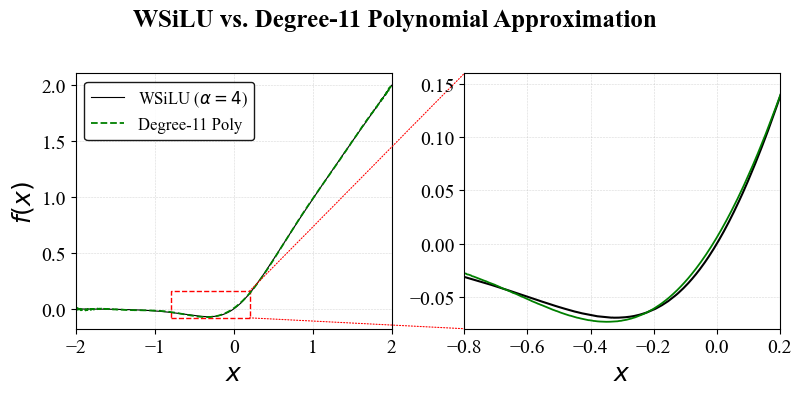

In [66]:

x = np.linspace(-2, 2, 1000, dtype=np.float16)


ys_real = wsilu_real(x)
ys_lut_pol11 = np.array([WSiLU_poly11(val) for val in x])

# --- Definição da Região do Super Zoom ---
zoom_x1, zoom_x2 = -0.8, 0.2
zoom_y1, zoom_y2 = -0.08, 0.16

plt.rcParams.update({
    "font.family": FONT_WINDOWS,
    "axes.labelsize": LABELS_FONT_SIZE,
    "xtick.labelsize": TICK_FONT_SIZE,
    "ytick.labelsize": TICK_FONT_SIZE,
    "legend.fontsize": LEGEND_FONT_SIZE
})


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(FIGURE_WIDTH, FIGURE_HEIGHT))


ax1.plot(x, ys_real, label=r"WSiLU ($\alpha=4$)", color="black", linestyle="-", linewidth=0.8)
ax1.plot(x, ys_lut_pol11, label=r"Degree-11 Poly", color="green", linestyle="--", linewidth=1.3)

ax1.set_xlim(-2, 2)
ax1.set_xlabel("$x$")
ax1.set_ylabel("$f(x)$")
ax1.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)
ax1.legend(loc="upper left", frameon=True, edgecolor="black", framealpha=0.9)

# Adiciona o retângulo 
rect = Rectangle(
    (zoom_x1, zoom_y1),
    zoom_x2 - zoom_x1,
    zoom_y2 - zoom_y1,
    linewidth=1.0,
    edgecolor='red',
    linestyle='--',
    facecolor='none'
)
ax1.add_patch(rect)

# ============
# Super Zoom 
# ============
ax2.plot(x, ys_real, color="black", linestyle="-", linewidth=1.5)
ax2.plot(x, ys_lut_pol11, color="green", linestyle="-", linewidth=1.3)

# Trava os eixos estritamente na região do retângulo
ax2.set_xlim(zoom_x1, zoom_x2)
ax2.set_ylim(zoom_y1, zoom_y2)

ax2.set_xlabel("$x$")
ax2.grid(True, which="both", linestyle="--", linewidth=0.4, alpha=0.5)


con1 = ConnectionPatch(xyA=(zoom_x2, zoom_y2), xyB=(zoom_x1, zoom_y2), 
                        coordsA="data", coordsB="data",
                        axesA=ax1, axesB=ax2, 
                        linestyle=":", linewidth=0.8, color="red")

con2 = ConnectionPatch(xyA=(zoom_x2, zoom_y1), xyB=(zoom_x1, zoom_y1), 
                        coordsA="data", coordsB="data",
                        axesA=ax1, axesB=ax2, 
                        linestyle=":", linewidth=0.8, color="red")

ax2.add_artist(con1)
ax2.add_artist(con2)

fig.suptitle("WSiLU vs. Degree-11 Polynomial Approximation", 
             fontsize=TITLE_FONT_SIZE, weight='bold', y=0.98)


plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.subplots_adjust(wspace=0.23)
plt.savefig(FIGURES_PATH + "/real_vs_appr_zoomPol11.pdf", dpi=1200, bbox_inches="tight")
plt.show()

## ALL


In [110]:
from matplotlib.patches import Rectangle, ConnectionPatch

def plot_comparison(ax1, ax2,
                    x,
                    ys_real,
                    ys_approx,
                    title,
                    color="green",
                    zoom_x1=-0.8,
                    zoom_x2=0.2,
                    zoom_y1=-0.08,
                    zoom_y2=0.16):

    # =========================
    # Gráfico completo
    # =========================
    ax1.plot(
        x, ys_real,
        color="black",
        linewidth=0.8
    )

    ax1.plot(
        x, ys_approx,
        color=color,
        linestyle="-",
        linewidth=1.0
    )

    ax1.set_xlim(-2, 2)
    ax1.grid(True, linestyle="--", linewidth=0.3, alpha=0.6)

    # Retângulo da região ampliada
    rect = Rectangle(
        (zoom_x1, zoom_y1),
        zoom_x2 - zoom_x1,
        zoom_y2 - zoom_y1,
        edgecolor="red",
        linestyle="--",
        linewidth=1.0,
        facecolor="none"
    )

    ax1.add_patch(rect)

    ax1.text(
        0.02, 0.95,
        title,
        transform=ax1.transAxes,
        fontsize=TITLE_FONT_SIZE,
        fontweight="bold",
        va="top",
        ha="left"
    )

    # =========================
    # Zoom
    # =========================
    ax2.plot(
        x, ys_real,
        color="black",
        linewidth=0.8
    )

    ax2.plot(
        x, ys_approx,
        color=color,
        linestyle="-",
        linewidth=1.0
    )

    ax2.set_xlim(zoom_x1, zoom_x2)
    ax2.set_ylim(zoom_y1, zoom_y2)

    ax2.grid(True, linestyle="--", linewidth=0.3, alpha=0.6)

    # =========================
    # Conexões
    # =========================
    con1 = ConnectionPatch(
        xyA=(zoom_x2, zoom_y2),
        xyB=(zoom_x1, zoom_y2),
        coordsA="data",
        coordsB="data",
        axesA=ax1,
        axesB=ax2,
        color="red",
        linestyle=":",
        linewidth=0.8
    )

    con2 = ConnectionPatch(
        xyA=(zoom_x2, zoom_y1),
        xyB=(zoom_x1, zoom_y1),
        coordsA="data",
        coordsB="data",
        axesA=ax1,
        axesB=ax2,
        color="red",
        linestyle=":",
        linewidth=0.8
    )

    ax2.add_artist(con1)
    ax2.add_artist(con2)

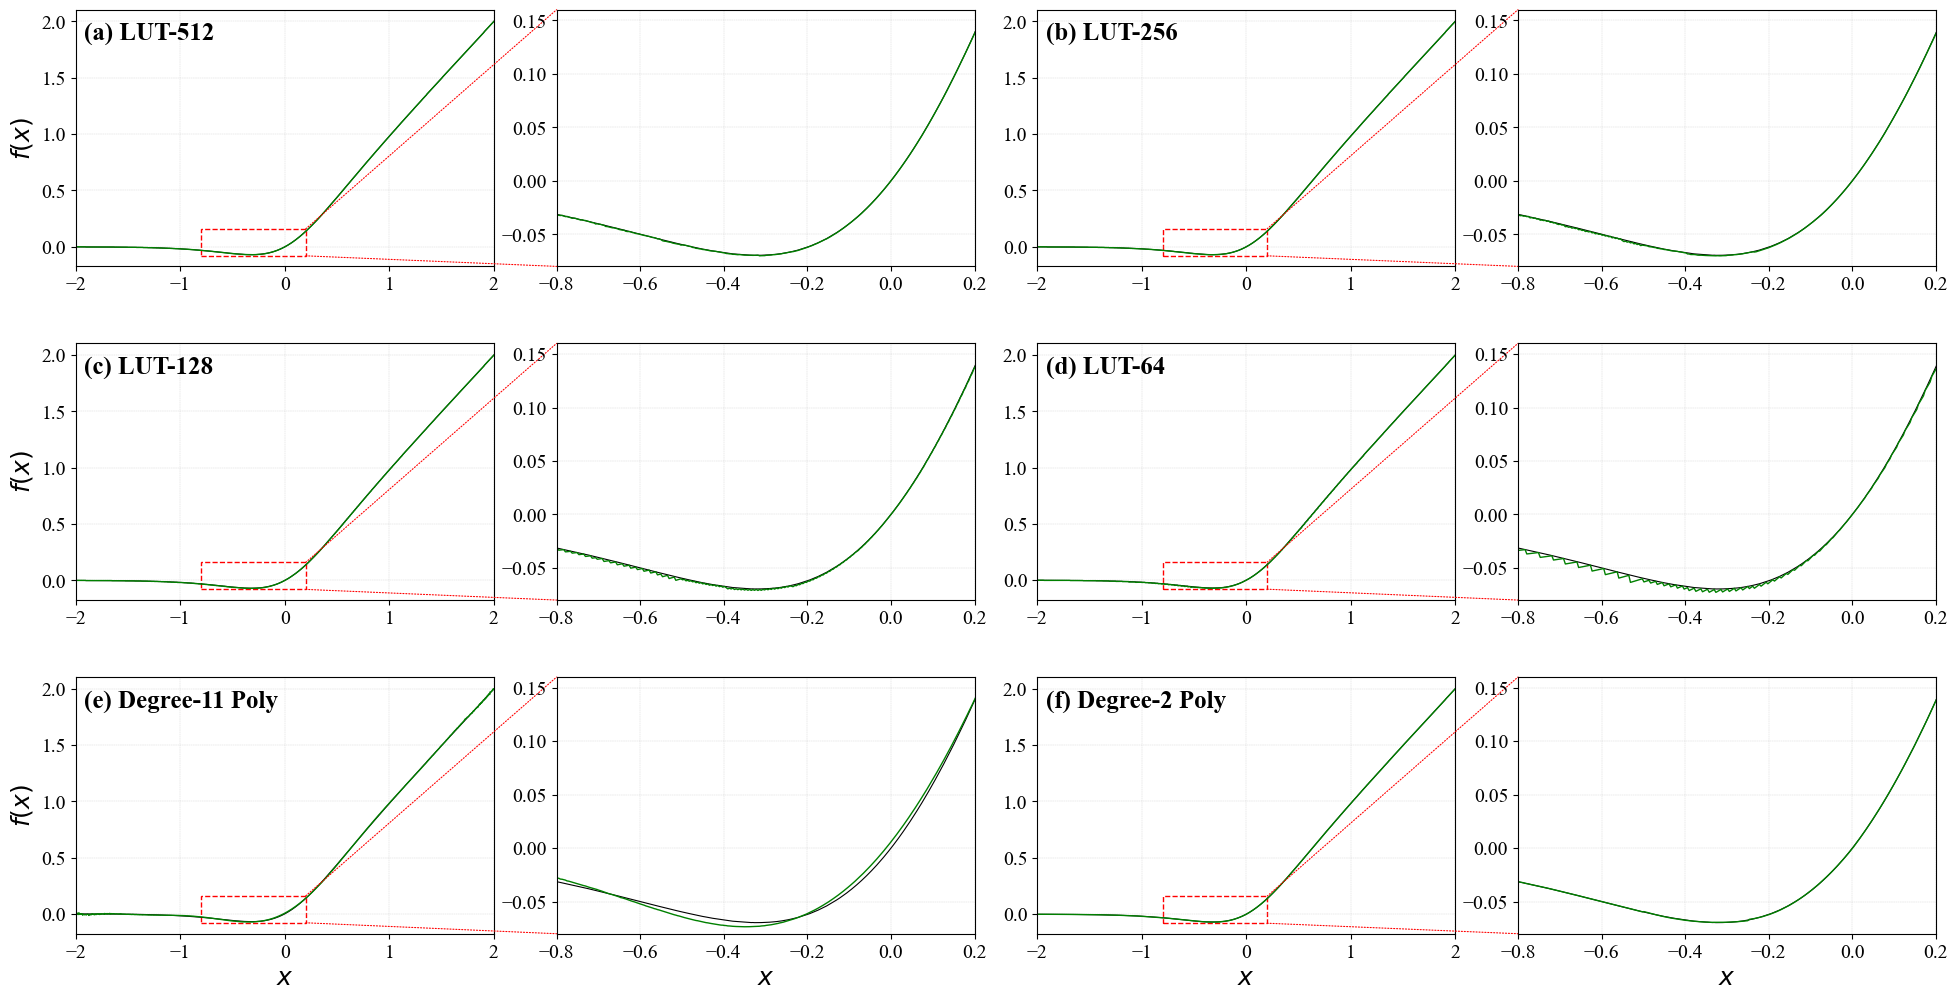

In [111]:
fig, axs = plt.subplots(
    3, 4,
    figsize=(3*FIGURE_WIDTH, 3*FIGURE_HEIGHT)
)

# =========================
# Linha 1
# =========================

plot_comparison(
    axs[0,0], axs[0,1],
    x, ys_real, ys_lut_512,
    "(a) LUT-512"
)

plot_comparison(
    axs[0,2], axs[0,3],
    x, ys_real, ys_lut_256,
    "(b) LUT-256"
)

plot_comparison(
    axs[1,0], axs[1,1],
    x, ys_real, ys_lut_128,
    "(c) LUT-128"
)

plot_comparison(
    axs[1,2], axs[1,3],
    x, ys_real, ys_lut_64,
    "(d) LUT-64"
)

plot_comparison(
    axs[2,0], axs[2,1],
    x, ys_real, ys_lut_pol11,
    "(e) Degree-11 Poly"
)

plot_comparison(
    axs[2,2], axs[2,3],
    x, ys_real, ys_lut_pol2,
    "(f) Degree-2 Poly"
)

# =========================
# Ajustes finais
# =========================

for ax in axs[:, 0]:
    ax.set_ylabel(r"$f(x)$")

for ax in axs[2, :]:
    ax.set_xlabel(r"$x$")

fig.subplots_adjust(
    wspace=0.15,
    hspace=0.30
)

plt.savefig(
    FIGURES_PATH + "/all_wsilu_approximations.pdf",
    dpi=1200,
    bbox_inches="tight"
)

plt.show()

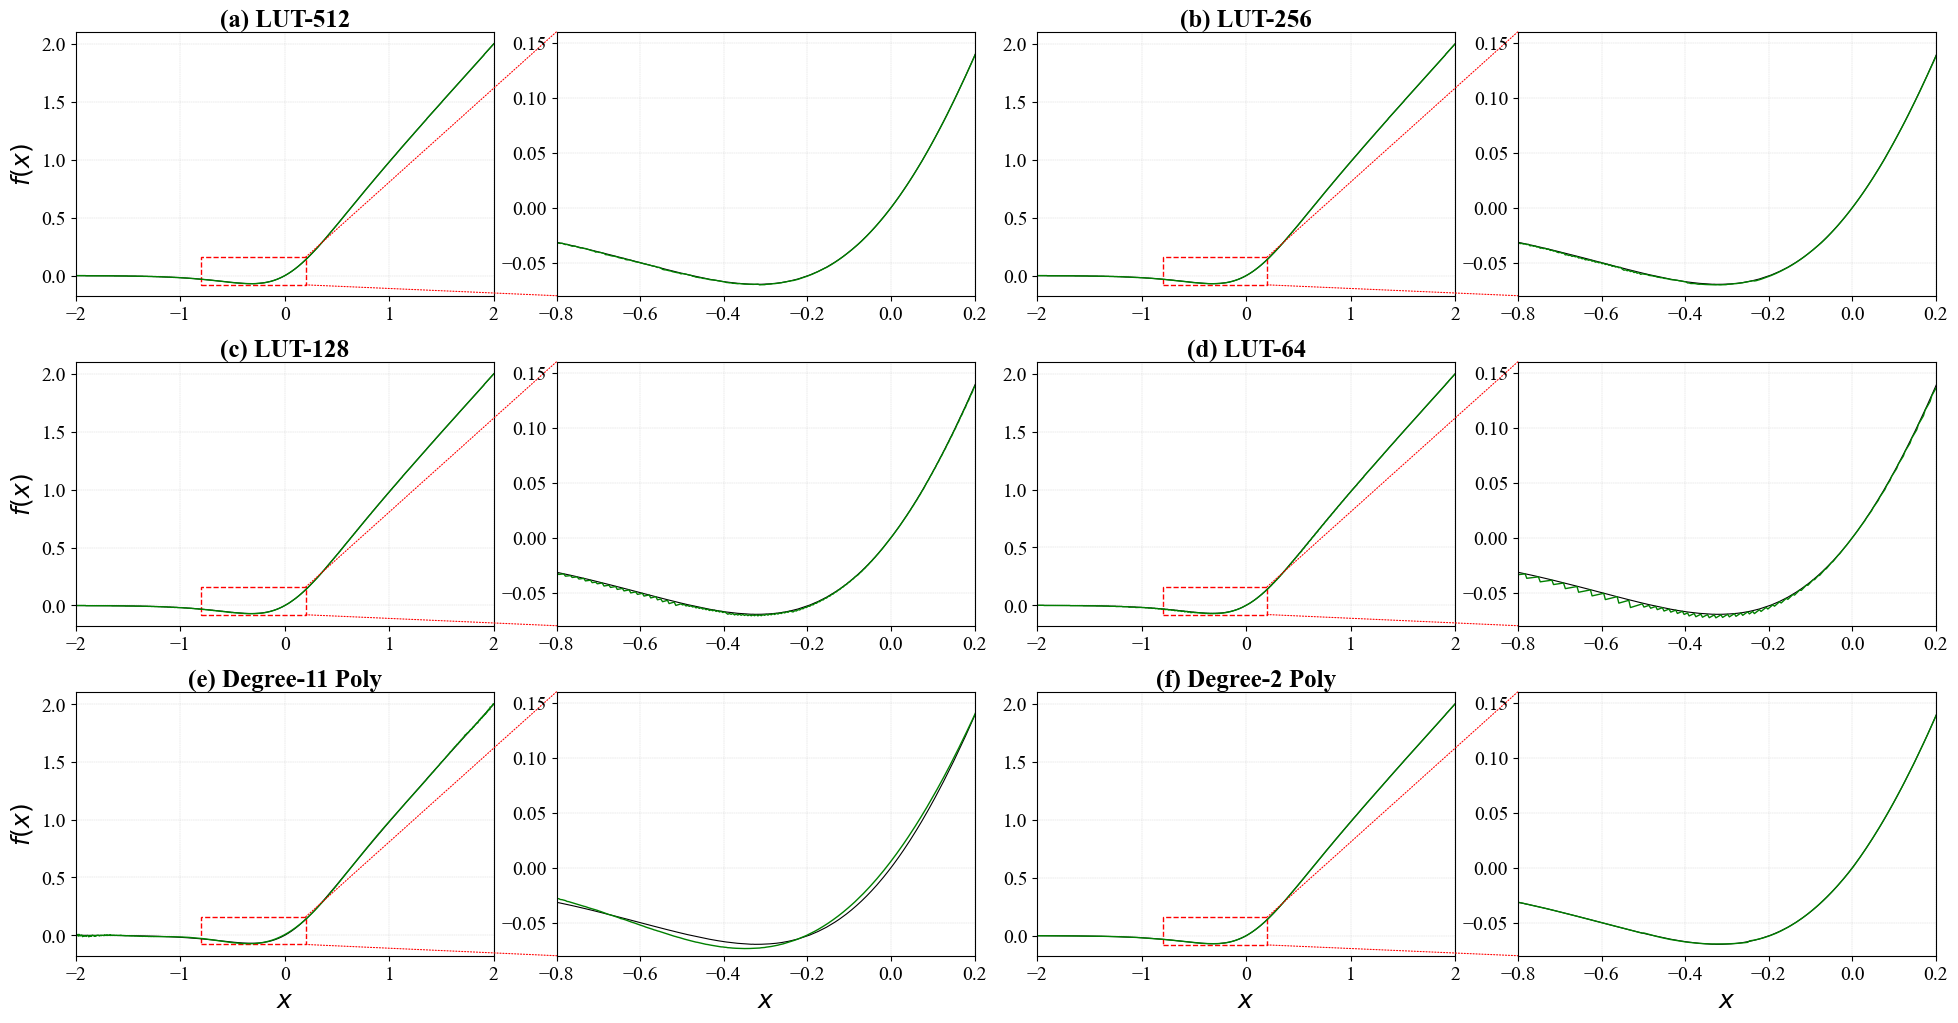

In [120]:
from matplotlib.patches import Rectangle, ConnectionPatch

def plot_comparison(ax1, ax2,
                    x,
                    ys_real,
                    ys_approx,
                    title,
                    color="green",
                    zoom_x1=-0.8,
                    zoom_x2=0.2,
                    zoom_y1=-0.08,
                    zoom_y2=0.16):

    # =========================
    # Gráfico completo
    # =========================
    ax1.plot(
        x, ys_real,
        color="black",
        linewidth=0.8
    )

    ax1.plot(
        x, ys_approx,
        color=color,
        linestyle="-",
        linewidth=1.0
    )

    ax1.set_xlim(-2, 2)
    ax1.grid(True, linestyle="--", linewidth=0.3, alpha=0.6)

    # Retângulo da região ampliada
    rect = Rectangle(
        (zoom_x1, zoom_y1),
        zoom_x2 - zoom_x1,
        zoom_y2 - zoom_y1,
        edgecolor="red",
        linestyle="--",
        linewidth=1.0,
        facecolor="none"
    )

    ax1.add_patch(rect)

    ax1.set_title(
    title,
    fontsize=LABELS_FONT_SIZE,
    fontweight="bold",
    pad=2
)

    # =========================
    # Zoom
    # =========================
    ax2.plot(
        x, ys_real,
        color="black",
        linewidth=0.8
    )

    ax2.plot(
        x, ys_approx,
        color=color,
        linestyle="-",
        linewidth=1.0
    )

    ax2.set_xlim(zoom_x1, zoom_x2)
    ax2.set_ylim(zoom_y1, zoom_y2)

    ax2.grid(True, linestyle="--", linewidth=0.3, alpha=0.6)

    # =========================
    # Conexões
    # =========================
    con1 = ConnectionPatch(
        xyA=(zoom_x2, zoom_y2),
        xyB=(zoom_x1, zoom_y2),
        coordsA="data",
        coordsB="data",
        axesA=ax1,
        axesB=ax2,
        color="red",
        linestyle=":",
        linewidth=0.8
    )

    con2 = ConnectionPatch(
        xyA=(zoom_x2, zoom_y1),
        xyB=(zoom_x1, zoom_y1),
        coordsA="data",
        coordsB="data",
        axesA=ax1,
        axesB=ax2,
        color="red",
        linestyle=":",
        linewidth=0.8
    )

    ax2.add_artist(con1)
    ax2.add_artist(con2)


fig, axs = plt.subplots(
    3, 4,
    figsize=(3*FIGURE_WIDTH, 3*FIGURE_HEIGHT)
)

# =========================
# Linha 1
# =========================

plot_comparison(
    axs[0,0], axs[0,1],
    x, ys_real, ys_lut_512,
    "(a) LUT-512"
)

plot_comparison(
    axs[0,2], axs[0,3],
    x, ys_real, ys_lut_256,
    "(b) LUT-256"
)

plot_comparison(
    axs[1,0], axs[1,1],
    x, ys_real, ys_lut_128,
    "(c) LUT-128"
)

plot_comparison(
    axs[1,2], axs[1,3],
    x, ys_real, ys_lut_64,
    "(d) LUT-64"
)

plot_comparison(
    axs[2,0], axs[2,1],
    x, ys_real, ys_lut_pol11,
    "(e) Degree-11 Poly"
)

plot_comparison(
    axs[2,2], axs[2,3],
    x, ys_real, ys_lut_pol2,
    "(f) Degree-2 Poly"
)

# =========================
# Ajustes finais
# =========================

for ax in axs[:, 0]:
    ax.set_ylabel(r"$f(x)$")

for ax in axs[2, :]:
    ax.set_xlabel(r"$x$")

fig.subplots_adjust(
    wspace=0.15,
    hspace=0.25
)

plt.savefig(
    FIGURES_PATH + "/all_wsilu_approximations2.pdf",
    dpi=1200,
    bbox_inches="tight"
)

plt.show()

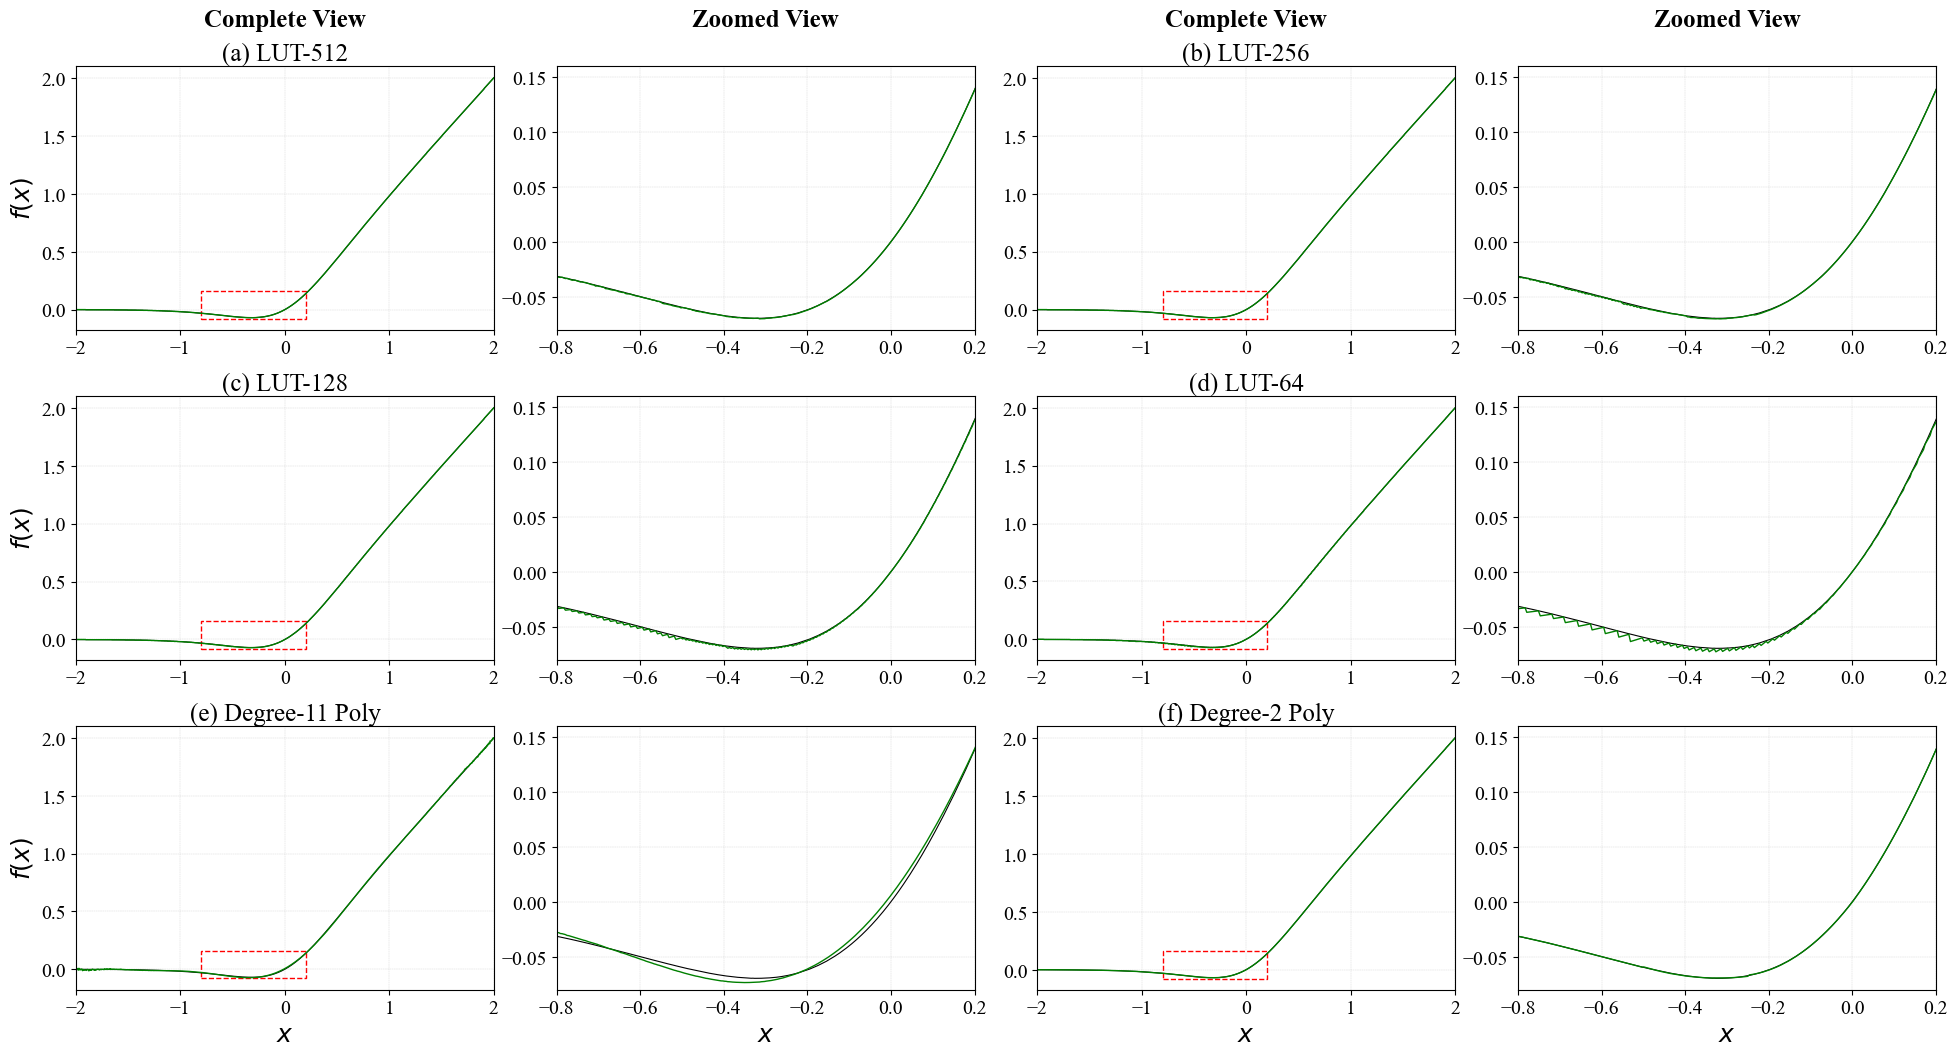

In [122]:
from matplotlib.patches import Rectangle, ConnectionPatch

def plot_comparison(ax1, ax2,
                    x,
                    ys_real,
                    ys_approx,
                    title,
                    color="green",
                    zoom_x1=-0.8,
                    zoom_x2=0.2,
                    zoom_y1=-0.08,
                    zoom_y2=0.16):

    # =========================
    # Gráfico completo
    # =========================
    ax1.plot(
        x, ys_real,
        color="black",
        linewidth=0.8
    )

    ax1.plot(
        x, ys_approx,
        color=color,
        linestyle="-",
        linewidth=1.0
    )

    ax1.set_xlim(-2, 2)
    ax1.grid(True, linestyle="--", linewidth=0.3, alpha=0.6)

    # Retângulo da região ampliada
    rect = Rectangle(
        (zoom_x1, zoom_y1),
        zoom_x2 - zoom_x1,
        zoom_y2 - zoom_y1,
        edgecolor="red",
        linestyle="--",
        linewidth=1.0,
        facecolor="none"
    )

    ax1.add_patch(rect)

    ax1.set_title(
    title,
    fontsize=LABELS_FONT_SIZE,
    pad=2
)


    ax2.plot(
        x, ys_real,
        color="black",
        linewidth=0.8
    )

    ax2.plot(
        x, ys_approx,
        color=color,
        linestyle="-",
        linewidth=1.0
    )

    ax2.set_xlim(zoom_x1, zoom_x2)
    ax2.set_ylim(zoom_y1, zoom_y2)

    ax2.grid(True, linestyle="--", linewidth=0.3, alpha=0.6)

fig, axs = plt.subplots(
    3, 4,
    figsize=(3*FIGURE_WIDTH, 3*FIGURE_HEIGHT)
)

# =========================
# Linha 1
# =========================

plot_comparison(
    axs[0,0], axs[0,1],
    x, ys_real, ys_lut_512,
    "(a) LUT-512"
)

plot_comparison(
    axs[0,2], axs[0,3],
    x, ys_real, ys_lut_256,
    "(b) LUT-256"
)

plot_comparison(
    axs[1,0], axs[1,1],
    x, ys_real, ys_lut_128,
    "(c) LUT-128"
)

plot_comparison(
    axs[1,2], axs[1,3],
    x, ys_real, ys_lut_64,
    "(d) LUT-64"
)

plot_comparison(
    axs[2,0], axs[2,1],
    x, ys_real, ys_lut_pol11,
    "(e) Degree-11 Poly"
)

plot_comparison(
    axs[2,2], axs[2,3],
    x, ys_real, ys_lut_pol2,
    "(f) Degree-2 Poly"
)
# Cabeçalhos das colunas
axs[0,0].text(
    0.5, 1.15,
    "Complete View",
    transform=axs[0,0].transAxes,
    ha="center",
    fontsize=LABELS_FONT_SIZE,
    fontweight="bold"
)

axs[0,1].text(
    0.5, 1.15,
    "Zoomed View",
    transform=axs[0,1].transAxes,
    ha="center",
    fontsize=LABELS_FONT_SIZE,
    fontweight="bold"
)

axs[0,2].text(
    0.5, 1.15,
    "Complete View",
    transform=axs[0,2].transAxes,
    ha="center",
    fontsize=LABELS_FONT_SIZE,
    fontweight="bold"
)

axs[0,3].text(
    0.5, 1.15,
    "Zoomed View",
    transform=axs[0,3].transAxes,
    ha="center",
    fontsize=LABELS_FONT_SIZE,
    fontweight="bold"
)
# =========================
# Ajustes finais
# =========================

for ax in axs[:, 0]:
    ax.set_ylabel(r"$f(x)$")

for ax in axs[2, :]:
    ax.set_xlabel(r"$x$")

fig.subplots_adjust(
    wspace=0.15,
    hspace=0.25
)

plt.savefig(
    FIGURES_PATH + "/all_wsilu_approximations3.pdf",
    dpi=1200,
    bbox_inches="tight"
)

plt.show()